# Búsquedas Hoteleras (TP1)

## 1. Planteamiento del problema

ID90Travel es una plataforma utilizada por empleados de aerolíneas para realizar búsquedas de alojamiento a tarifas preferenciales. Uno de los principales desafíos al analizar los precios obtenidos en estas búsquedas es determinar si un determinado valor puede considerarse bajo, normal o elevado.

El precio de una noche, por sí solo, no permite establecer esta clasificación. Un mismo valor puede representar condiciones de mercado muy diferentes dependiendo del destino, la época del año, la duración de la estadía o las características de la búsqueda.

Por este motivo, se plantea la necesidad de construir un mecanismo que permita comparar un nuevo precio con un conjunto de observaciones históricas similares y, a partir de esa comparación, determinar su posición relativa dentro de la distribución de precios.

Este planteamiento requiere resolver dos cuestiones:

* **¿Con qué precios debe compararse una observación?**
  Es necesario definir un conjunto de observaciones históricas que puedan considerarse comparables. Para ello se deben analizar distintas dimensiones, como destino, período del año, duración de la estadía o características de la búsqueda.

* **¿Cómo determinar si un precio es bajo o elevado?**
  Una vez definido el conjunto de comparación, se debe establecer un criterio estadístico que permita clasificar el precio observado.

El presente TP1 se concentra principalmente en la primera cuestión. El objetivo es realizar un análisis exploratorio que permita identificar qué variables y segmentaciones contribuyen a definir grupos de precios homogéneos y, por lo tanto, comparables entre sí.

## 2. Descripción de los datos

Cada registro del dataset representa el resultado agregado de una búsqueda hotelera. Por ejemplo, una búsqueda puede estar determinada por un destino, un período de estadía, una cantidad de adultos y una cantidad de habitaciones. El registro resume la información obtenida a partir del conjunto de hoteles disponibles para esa búsqueda.

Entre las principales variables utilizadas se encuentran:

* **`city`, `state`, `country`**: destino asociado a la búsqueda.
* **`date_start`, `date_end`, `nights`**: fecha de inicio, fecha de finalización y duración de la estadía.
* **`number_of_adults`, `number_of_rooms`, `number_of_kids`**: características de los pasajeros y de la reserva.
* **`avg_price_average`**: precio promedio de los hoteles obtenidos en la búsqueda. Es una de las principales variables de interés del análisis.
* **`avg_hotel_count`**: cantidad de hoteles disponibles para la búsqueda, utilizada como indicador de oferta.
* **`count_repeated`**: cantidad de búsquedas que comparten exactamente las mismas características, utilizada como aproximación a la demanda.

Un aspecto relevante del dataset es la gran cantidad de nombres de ciudades diferentes. Existen aproximadamente 26.000 valores distintos y algunos corresponden, en realidad, a un mismo destino representado mediante diferentes denominaciones (por ejemplo, *New York*, *New York City* o *NYC*).

Considerar cada denominación como un mercado independiente generaría numerosos grupos con muy pocas observaciones, dificultando la obtención de estadísticas representativas. Para reducir este problema, se dispone de un archivo adicional que permite asociar distintas ciudades con un **destino canónico**, agrupando aquellas que corresponden a una misma zona geográfica o mercado.

## 3. Pipeline de análisis

El análisis se estructura en las siguientes etapas:

```text
CSV(s) en data/
   → 1. Carga y exploración inicial
   → 2. Normalización de precios
   → 3. Expansión temporal de estadías de múltiples noches
   → 4. Construcción de variables temporales (mes, semana del mes)
   → 5. Asociación de destinos mediante el mapping correspondiente
   → 6. Cálculo de estadísticas de referencia
   → 7. Clasificación de un precio de ejemplo
   → 8. TP1: análisis del método (datos originales → vista recortada → segmentación)
   → 9. TP1: clustering según perfil estacional y homogeneidad
   → 10. TP1: análisis del efecto del día de la semana y fin de semana
   → 11. TP1: análisis de la duración de la estadía (nights)
   → 12. TP1: análisis de la categoría de precio del hotel (low/medium/high)
   → 13. TP1: síntesis y ranking de homogeneidad entre dimensiones
   → 14. Conclusiones
```


In [ ]:
#Permiso para ver Google Drive (si se corre en Colab; comentar si es local)
from google.colab import drive
drive.mount('/content/drive')

#descarga una copia del código del proyecto desde GitHub hacia el disco temporal de la VM de Colab.
!git clone https://github.com/martinid90/id90-hotel-deals-analysis.git
%cd /content/id90-hotel-deals-analysis

# Instalamos las dependencias del proyecto SIN pisar numpy/pandas:
# requirements.txt pinea numpy==1.26.2 y pandas==2.1.4 (versiones de fines de
# 2023), que chocan con las que Colab ya trae preinstaladas y rompen el import
# con "numpy.dtype size changed". Dejamos que Colab use las suyas.
!pip install scipy==1.11.4 psycopg2-binary==2.9.9 python-dotenv -q

print("Listo. Ahora: Entorno de ejecución -> Reiniciar sesión, y después correr la Celda 2.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path 'id90-hotel-deals-analysis' already exists and is not an empty directory.
/content/id90-hotel-deals-analysis
Listo. Ahora: Entorno de ejecución -> Reiniciar sesión, y después correr la Celda 2.


In [ ]:
import sys
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%cd /content/id90-hotel-deals-analysis

# Importar funciones del sistema
sys.path.insert(0, str(Path('.').resolve()))
from auxiliary_functions import (
    load_all_historicals,
    load_destination_mapping,
    standardize_prices,
    expand_dates_dataframe,
    add_temporal_features,
    apply_destination_mapping,
    calculate_baselines,
    apply_robustness_checks,
    evaluate_hotel_price,
)
import config

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)
print('Librerías importadas correctamente')
print(f'Directorio de datos: {config.DATA_DIR}')

/content/id90-hotel-deals-analysis
Librerías importadas correctamente
Directorio de datos: /content/id90-hotel-deals-analysis/data


---
## Paso 1 — Carga de datos

**Función `load_all_historicals()`**: busca todos los archivos `datos_historicos_*.csv` en `config.DATA_DIR`, los carga con `pd.read_csv` y los concatena en un único DataFrame.

**Fix de muestreo**: en vez de quedarnos con las primeras 100k filas (sesgadas alfabéticamente por destino), tomamos 100.000 filas al azar de todo el archivo. `random_state=42` fija la semilla para que la muestra sea reproducible.

In [ ]:
#para cada uno de los 2 archivos de datos, arma la ruta de origen (en tu Drive) y la de destino (dentro de la carpeta data/ del repo clonado), y usa shutil.copy() para copiar el archivo físicamente de un lugar a otro. Al final, os.listdir() te muestra qué quedó en data/ — así confirmás que la copia funcionó.
import shutil, os

drive_path = '/content/drive/MyDrive/id90-project'
data_path = '/content/id90-hotel-deals-analysis/data'

for fname in ['datos_historicos_2024.csv', 'datos_historicos_2025.csv']:
    src = os.path.join(drive_path, fname)
    dst = os.path.join(data_path, fname)
    print(f'¿Existe origen? {os.path.exists(src)} -> {src}')
    shutil.copy(src, dst)
    print(f'Copiado: {fname}')

os.listdir(data_path)

¿Existe origen? True -> /content/drive/MyDrive/id90-project/datos_historicos_2024.csv
Copiado: datos_historicos_2024.csv
¿Existe origen? True -> /content/drive/MyDrive/id90-project/datos_historicos_2025.csv
Copiado: datos_historicos_2025.csv


['query_historicos_2025.py',
 'datos_historicos_2025.csv',
 'destination_with_nearest.csv',
 'datos_historicos_2024.csv',
 'query_historicos_2024.py']

In [ ]:
# Para esta demostración usamos una muestra ALEATORIA de 100.000 registros
# (semilla fija en 42 para que la muestra sea reproducible)
archivos = sorted(glob.glob(str(config.DATA_DIR / config.HISTORICALS_FILE_PATTERN)))
if not archivos:
    raise FileNotFoundError(f'No se encontraron archivos en {config.DATA_DIR}')

df_completo = pd.read_csv(archivos[0])
df_raw = df_completo.sample(n=100_000, random_state=42).reset_index(drop=True)
del df_completo  # ya no la necesitamos, libera memoria

print(f'Archivo:             {Path(archivos[0]).name}')
print(f'Registros cargados:  {len(df_raw):>12,}  (muestra aleatoria de 100k, seed=42)')
print(f'Columnas:            {len(df_raw.columns)}')
print()
print('Lista de columnas:')
for col in df_raw.columns:
    print(f'  - {col}  ({df_raw[col].dtype})')

/tmp/ipykernel_17743/3049566906.py:7: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_completo = pd.read_csv(archivos[0])


Archivo:             datos_historicos_2024.csv
Registros cargados:       100,000  (muestra aleatoria de 100k, seed=42)
Columnas:            17

Lista de columnas:
  - city  (object)
  - state  (object)
  - country  (object)
  - country_code  (object)
  - date_start  (object)
  - date_end  (object)
  - number_of_adults  (int64)
  - number_of_rooms  (int64)
  - number_of_kids  (int64)
  - nights  (int64)
  - count_repeated  (int64)
  - avg_hotel_count  (float64)
  - min_hotel_count  (int64)
  - max_hotel_count  (int64)
  - avg_price_average  (float64)
  - max_price_high  (float64)
  - min_price_low  (float64)


In [ ]:
#Chequeo de mayúscula/minúscula en country_code

print(df_raw['country_code'].unique()[:20])
print()
print('¿Están en mayúscula?', df_raw['country_code'].str.isupper().mean())
print('¿Están en minúscula?', df_raw['country_code'].str.islower().mean())

['us' 'jp' 'ph' 'cr' 'do' 'jm' 'th' 'ca' 'hn' 'co' 'vn' 'it' 'tw' nan 'mv'
 'mx' 'sv' 'nl' 'fr' 'tr']

¿Están en mayúscula? 0.0
¿Están en minúscula? 1.0


Confirma que viene en minúscula (us, jp...) en ~99.7% de los casos — dato que explica por qué el mapeo de destinos falla más adelante si no se corrige.


In [ ]:
# Cobertura temporal/geográfica (fechas, cantidad de países/ciudades, búsquedas totales) y un gráfico de barras de las 20 ciudades con más búsquedas,
#con el % que concentran las 5 principales. Es el "primer vistazo" estándar antes de transformar nada — sirve para detectar si hay algo raro
# (fechas fuera de rango, concentración extrema) antes de seguir.
#Cobertura temporal y geográfica
print('COBERTURA DEL DATASET')
print('=' * 45)
print(f"  Fecha inicio:       {df_raw['date_start'].min()}")
print(f"  Fecha fin:          {df_raw['date_start'].max()}")
print(f"  Países:             {df_raw['country'].nunique()}")
print(f"  Estados/Provincias: {df_raw['state'].nunique():,}")
print(f"  Ciudades:           {df_raw['city'].nunique():,}")
print()
print('DEMANDA (count_repeated = búsquedas agregadas)')
print('=' * 45)
print(f"  Total búsquedas:    {df_raw['count_repeated'].sum():,.0f}")
print(f"  Media por registro: {df_raw['count_repeated'].mean():.1f}")
print()
print('PRECIOS (avg_price_average)')
print('=' * 45)
df_raw['avg_price_average'].describe()

COBERTURA DEL DATASET
  Fecha inicio:       2024-01-01
  Fecha fin:          2024-12-30
  Países:             203
  Estados/Provincias: 1,043
  Ciudades:           10,393

DEMANDA (count_repeated = búsquedas agregadas)
  Total búsquedas:    712,640
  Media por registro: 7.1

PRECIOS (avg_price_average)


,avg_price_average
count,100000.00
mean,277.07
std,637.21
min,5.56
25%,124.09
50%,180.90
75%,286.78
max,89871.48


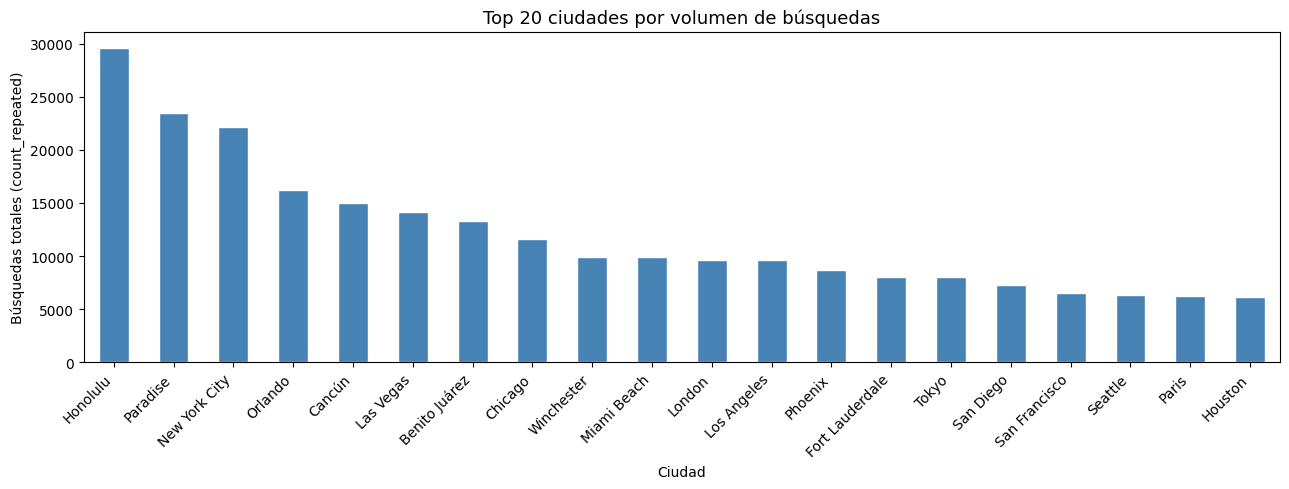

Top 5 ciudades concentran el 14.9% del total de búsquedas.


In [ ]:
# TP1: Top destinos por volumen de búsquedas
top_dest = (
    df_raw.groupby('city')['count_repeated']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(13, 5))
top_dest.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 ciudades por volumen de búsquedas', fontsize=13)
ax.set_xlabel('Ciudad')
ax.set_ylabel('Búsquedas totales (count_repeated)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

top5_pct = top_dest.head(5).sum() / df_raw['count_repeated'].sum()
print(f'Top 5 ciudades concentran el {top5_pct:.1%} del total de búsquedas.')

---
## Paso 2 — Normalización de precios

```
precio_normalizado = precio_total / (noches × habitaciones × (adultos + niños))
```

Esto produce un **precio por persona por habitación por noche**, comparable entre búsquedas de cualquier composición. Esta es la variable central de análisis del sistema.



In [ ]:
#Saca filas duplicadas exactas y llama a standardize_prices(), que calcula:

#precio_normalizado = precio_total / (noches × habitaciones × (adultos + niños))

registros_antes = len(df_raw)
df = df_raw.drop_duplicates()
print(f'Duplicados eliminados: {registros_antes - len(df):,}')
print()

df = standardize_prices(df)
print('Nuevas columnas agregadas:')
print('  - avg_price_average_std  (precio promedio normalizado)')
print('  - max_price_high_std     (precio máximo normalizado)')
print('  - min_price_low_std      (precio mínimo normalizado)')
print()
df[['avg_price_average', 'avg_price_average_std']].describe()

Duplicados eliminados: 0

Nuevas columnas agregadas:
  - avg_price_average_std  (precio promedio normalizado)
  - max_price_high_std     (precio máximo normalizado)
  - min_price_low_std      (precio mínimo normalizado)



,avg_price_average,avg_price_average_std
count,100000.00,100000.00
mean,277.07,258.81
std,637.21,547.75
min,5.56,0.08
25%,124.09,115.73
50%,180.90,172.23
75%,286.78,275.29
max,89871.48,89871.48


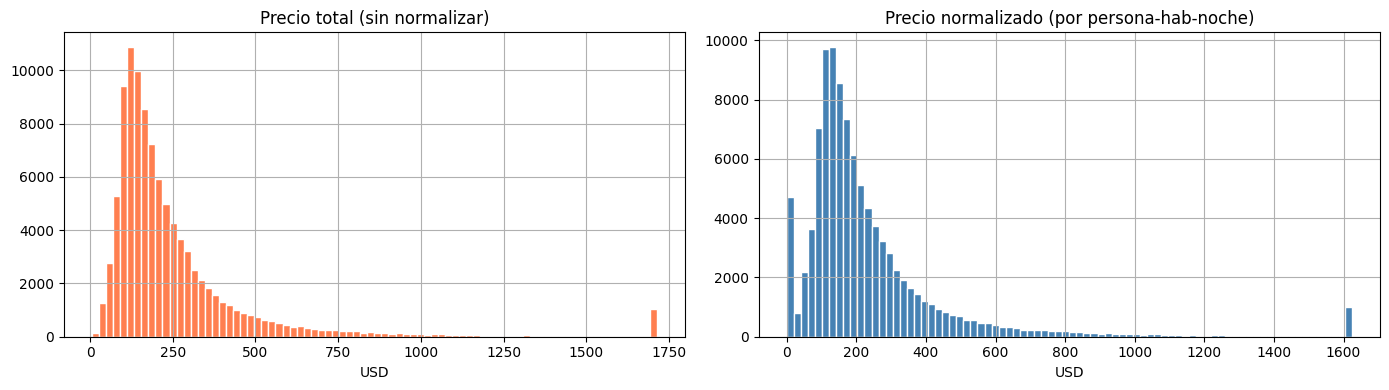

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

clip_raw = df['avg_price_average'].quantile(0.99)
df['avg_price_average'].clip(upper=clip_raw).hist(bins=80, ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Precio total (sin normalizar)')
axes[0].set_xlabel('USD')

clip_std = df['avg_price_average_std'].quantile(0.99)
df['avg_price_average_std'].clip(upper=clip_std).hist(bins=80, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Precio normalizado (por persona-hab-noche)')
axes[1].set_xlabel('USD')

plt.tight_layout()
plt.show()

---
## Paso 3 — Expansión temporal


Cada fila original representa una estadía de varias noches. Esta función convierte cada fila en N filas (una por noche), preservando el resto de los datos. Es necesario para poder analizar más adelante efectos por noche específica (día de la semana, mes) en vez de por estadía completa.


In [ ]:
registros_antes = len(df)
df = expand_dates_dataframe(df)
print(f'Registros antes:   {registros_antes:>12,}')
print(f'Registros después: {len(df):>12,}')
print(f'Factor expansión:  {len(df)/registros_antes:.2f}x')
df[['date_start', 'date_end', 'nights', 'date']].head()

Registros antes:        100,000
Registros después:      427,049
Factor expansión:  4.27x


,date_start,date_end,nights,date
0,2024-05-11,2024-05-12,1,2024-05-11
0,2024-05-11,2024-05-12,1,2024-05-12
1,2024-08-30,2024-08-31,1,2024-08-30
1,2024-08-30,2024-08-31,1,2024-08-31
2,2024-03-04,2024-03-07,3,2024-03-04


---
## Paso 4 — Features temporales

- `month`: mes del año (1–12)
- `week_in_month`: semana del mes (1–4) — días 1–7, 8–15, 16–22, 23–31

Agrega month (1-12) y week_in_month (1-4), calculados a partir de la columna date que dejó la expansión del Paso 3. Son la base para armar "contextos" temporales más adelante (destino × mes × semana).


In [ ]:
df = add_temporal_features(df)
print('Columnas agregadas: month, week_in_month')
df[['date', 'month', 'week_in_month']].head()

Columnas agregadas: month, week_in_month


,date,month,week_in_month
0,2024-05-11,5,2
0,2024-05-12,5,2
1,2024-08-30,8,4
1,2024-08-31,8,4
2,2024-03-04,3,1


**Gráfico de barras:** precio normalizado promedio por mes — primer vistazo a estacionalidad general, antes de mirarla por destino o segmento.


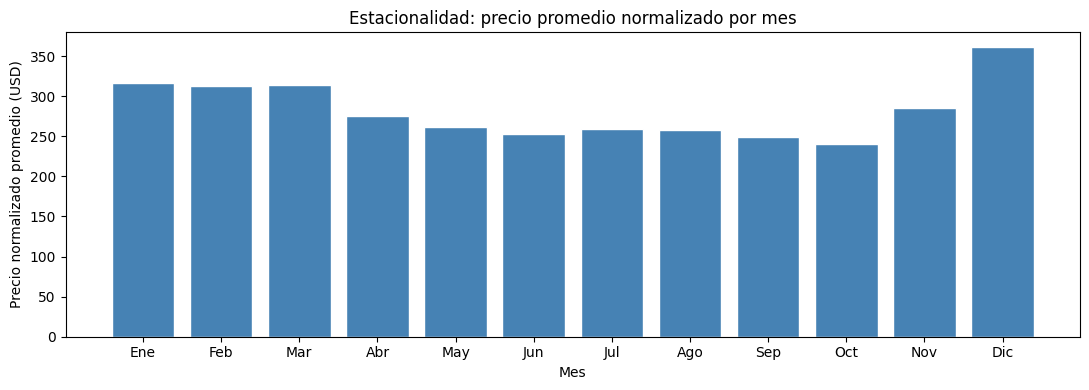

In [ ]:
precios_mes = df.groupby('month')['avg_price_average_std'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(precios_mes['month'], precios_mes['avg_price_average_std'], color='steelblue', edgecolor='white')
ax.set_xlabel('Mes')
ax.set_ylabel('Precio normalizado promedio (USD)')
ax.set_title('Estacionalidad: precio promedio normalizado por mes')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
plt.tight_layout()
plt.show()

---
## Paso 5 — Mapping de destinos (combinación de índices)

El dataset contiene ~26.000 nombres de ciudades distintos, muchos de ellos variantes del mismo lugar. Se consolidan usando la clave compuesta `country_code - state_code - city`.

Carga destination_with_nearest.csv: un archivo que agrupa ~26.000 nombres de ciudad distintos bajo un "destino canónico" (por ejemplo, "New York" y "NYC" caen bajo el mismo nearest_destination_id). Sin esto, la mayoría de las ciudades tendrían tan pocas búsquedas que ningún análisis sería confiable.


In [ ]:
mapping_df = load_destination_mapping()
print(f'Referencias en el mapping: {len(mapping_df):,}')
print(f'Destinos canónicos únicos: {mapping_df["nearest_destination_id"].nunique():,}')
mapping_df.head()

Referencias en el mapping: 15,988
Destinos canónicos únicos: 2,584


,reference,city,latitude,longitude,nearest_destination_id,nearest_destination_name
0,AD - Andorra La Bella,Andorra La Bella,42.51,1.53,50643,Andorra la Vella
1,AD - Andorra La Vella,Andorra La Vella,42.51,1.53,50643,Andorra la Vella
2,AD - Arinsal,Arinsal,42.58,1.48,50643,Andorra la Vella
3,AD - El Pas de la Casa,El Pas de la Casa,42.54,1.73,21795,Andorra
4,AD - Escaldes-Engordany,Escaldes-Engordany,42.51,1.54,50643,Andorra la Vella


La función apply_destination_mapping arma una clave de búsqueda country_code - state_code - city para matchear contra el archivo de mapping, pero usa country_code tal cual viene en el dataset — en minúscula — mientras que el archivo de mapping usa mayúscula. El join falla silenciosamente para casi todo. Acá se reconstruye la misma lógica a mano, agregando .str.upper() para igualar el formato. Cuando el join no encuentra match, destination_final cae en un fallback: usa el nombre de ciudad crudo en vez de quedar vacío (fillna(df['city'])).


In [ ]:
# Aplicamos el mapping de destinos a mano (no con apply_destination_mapping) porque esa
# función arma 'reference' con country_code tal cual viene del dataset, en minúscula
# ('us', 'jp'...), y el archivo de mapping usa códigos en mayúscula ('US', 'JP'...) --
# el merge fallaba silenciosamente para casi todos los registros.
STATE_CODES = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO',
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH',
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT',
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

df['state_code'] = df['state'].map(STATE_CODES)
df['reference'] = df['country_code'].str.upper() + ' - ' + df['state_code'].fillna('') + ' - ' + df['city']

mapping_indexed = mapping_df[['reference', 'city', 'nearest_destination_id', 'nearest_destination_name']].copy()
mapping_indexed = mapping_indexed.set_index(['reference', 'city'])

df = df.merge(mapping_indexed, left_on=['reference', 'city'], right_index=True, how='left', copy=False)

df['destination_final'] = df['nearest_destination_id'].fillna(df['city'])
df['destination_name'] = df['nearest_destination_name'].fillna(df['city'])

matched = df['nearest_destination_id'].notna().sum()
total = len(df)
print(f'Mapping aplicado: {matched:,}/{total:,} registros ({100*matched/total:.1f}%)')
print(f'Destinos únicos: {df["destination_final"].nunique():,}')

Mapping aplicado: 124,494/427,049 registros (29.2%)
Destinos únicos: 8,986


El match es 0%; con .str.upper(), sube a 29.2%. El 70.8% restante no matchea ni así, porque el archivo de mapping usa un formato de 2 partes (país-ciudad) para todo el mundo excepto EE.UU., que usa 3 partes (país-estado-ciudad) — y STATE_CODES solo cubre estados de EE.UU.


In [ ]:
resultados = {}

# Limpiamos las columnas que dejó el mapping manual del Paso 5, para que
# apply_destination_mapping() arranque desde cero y no choque con columnas
# que ya existen (si no, el merge interno las duplica con sufijos _x/_y
# y la función no encuentra 'nearest_destination_id').
columnas_mapping = ['reference', 'state_code', 'nearest_destination_id',
                     'nearest_destination_name', 'destination_final', 'destination_name']

df_a = df.drop(columns=columnas_mapping, errors='ignore').copy()
df_a = apply_destination_mapping(df_a, mapping_df)  # función original del repo, sin upper
resultados['original (repo, sin upper)'] = df_a['nearest_destination_id'].notna().mean()

df_b = df.drop(columns=columnas_mapping, errors='ignore').copy()
df_b['state_code'] = df_b['state'].map(STATE_CODES)
df_b['reference'] = df_b['country_code'].str.upper() + ' - ' + df_b['state_code'].fillna('') + ' - ' + df_b['city']
mapping_indexed = mapping_df.set_index(['reference', 'city'])
df_b = df_b.merge(mapping_indexed[['nearest_destination_id']], left_on=['reference', 'city'], right_index=True, how='left')
resultados['manual + upper (tu versión)'] = df_b['nearest_destination_id'].notna().mean()

for k, v in resultados.items():
    print(f'{k:30s}: {v:.1%} de match')

original (repo, sin upper)    : 0.0% de match
manual + upper (tu versión)   : 29.2% de match


Corre ambas versiones sobre el mismo df (limpiando primero las columnas que había dejado el mapping manual, para que la función original no choque con columnas ya existentes) y compara el % de match real. Resultado: 0.0% vs 29.2% — confirma empíricamente que el bug es real y que la corrección funciona.


---
## Paso 6 — Cálculo de baselines

Para cada contexto `(destino, mes, semana del mes)` se calcula media ponderada, desviación estándar, rango y cantidad de observaciones. Contextos con menos de 30 observaciones se marcan como `low_confidence`.

**Es la tabla de referencia contra la que después se compara cualquier precio nuevo.**

In [ ]:
baselines = calculate_baselines(df, enable_buckets=False)
baselines = apply_robustness_checks(baselines)

print('BASELINES CALCULADOS')
print('=' * 45)
print(f'  Total de contextos:          {len(baselines):>10,}')
print(f'  Alta confianza (>=30 obs):   {(~baselines["low_confidence"]).sum():>10,}  ({(~baselines["low_confidence"]).mean():.1%})')
print(f'  Baja confianza (<30 obs):    {baselines["low_confidence"].sum():>10,}  ({baselines["low_confidence"].mean():.1%})')
baselines.head()

BASELINES CALCULADOS
  Total de contextos:              57,989
  Alta confianza (>=30 obs):       11,409  (19.7%)
  Baja confianza (<30 obs):        46,580  (80.3%)


,destination_final,month,week_in_month,mean_price_std,std_price_std,min_price_std,max_price_std,count_obs,destination_name,low_confidence
0,77.00,1,3,105.12,10.51,44.39,806.86,28,USA,True
1,77.00,1,4,105.12,10.51,44.39,806.86,4,USA,True
2,77.00,2,3,82.56,8.26,47.60,135.45,1,USA,True
3,77.00,2,4,82.56,8.26,47.60,135.45,1,USA,True
4,77.00,4,1,110.54,11.05,36.53,301.00,3,USA,True


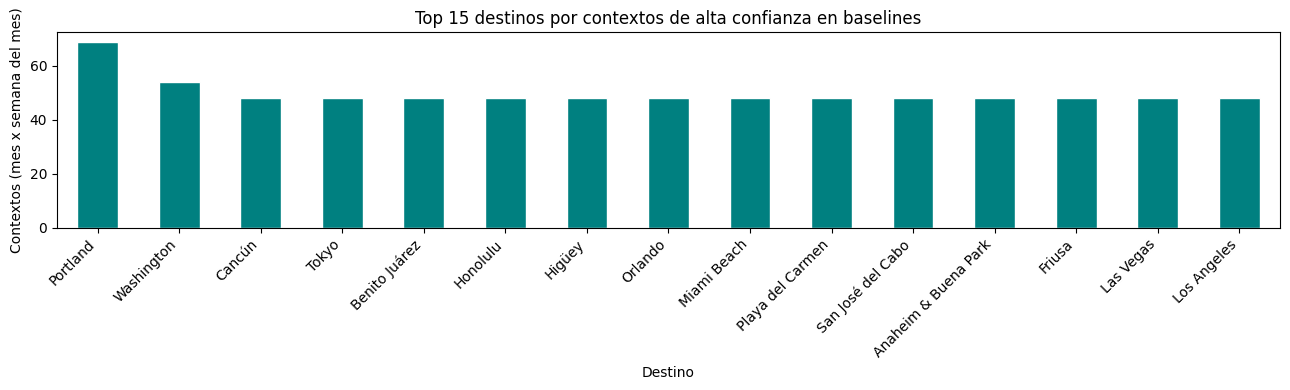

In [ ]:
top_baselines = (
    baselines[~baselines['low_confidence']]
    .groupby('destination_name')
    .size()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(13, 4))
top_baselines.plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('Top 15 destinos por contextos de alta confianza en baselines')
ax.set_xlabel('Destino')
ax.set_ylabel('Contextos (mes x semana del mes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## Paso 7 — Clasificación: z-score contextual

```
z = (precio_normalizado − media_histórica) / desviación_estándar_histórica
```

| Z-score | Clasificación |
|---------|---------------|
| z < -1.0 | **Deal** |
| -1.0 a -0.5 | **Good Price** |
| -0.5 a +0.5 | **Normal Price** |
| +0.5 a +1.0 | **Expensive** |
| z > +1.0 | **Very Expensive** |

Toma el destino con más contextos confiables, arma un precio de ejemplo ($300, 2 noches, 1 habitación, 2 adultos), lo normaliza con la misma fórmula del Paso 2, y llama a evaluate_hotel_price(), que calcula:

z = (precio_normalizado − media_histórica) / desvío_histórico

Con esto, clasifica el resultado (Deal / Good Price / Normal / Expensive / Very Expensive) según el rango en que cae z. Es una prueba de extremo a extremo del sistema completo con un solo ejemplo.


In [ ]:
dest_disponibles = (
    baselines[~baselines['low_confidence']]
    .groupby(['destination_final', 'destination_name'])
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='n_contextos')
)
print('Destinos con más contextos de alta confianza:')
print(dest_disponibles.to_string(index=False))

Destinos con más contextos de alta confianza:
destination_final     destination_name  n_contextos
    Benito Juárez        Benito Juárez           48
           645.00          Los Angeles           48
           797.00 Anaheim & Buena Park           48
San José del Cabo    San José del Cabo           48
           663.00              Orlando           48
 Playa del Carmen     Playa del Carmen           48
           Higüey               Higüey           48
           684.00            Las Vegas           48
      Miami Beach          Miami Beach           48
           Friusa               Friusa           48


In [ ]:
destination_id   = dest_disponibles.iloc[0]['destination_final']
destination_name = dest_disponibles.iloc[0]['destination_name']

price_total   = 300.0
nights        = 2
rooms         = 1
adults        = 2
kids          = 0
month         = 6
week_in_month = 2

persons = adults + kids if (adults + kids) > 0 else 1
price_std = price_total / (nights * rooms * persons)

result = evaluate_hotel_price(
    destination_final=destination_id,
    month=month,
    week_in_month=week_in_month,
    price_std=price_std,
    baselines_df=baselines
)

print(f'Destino: {destination_name} | precio normalizado: ${price_std:.2f}')
if result and result.get('classification') != 'Insufficient Data':
    print(f"Clasificación: {result.get('classification')}  (z = {result.get('z_score'):.3f}, confianza = {result.get('confidence')})")
else:
    print('Sin datos suficientes para este contexto — probar con otro mes/semana.')

Destino: Benito Juárez | precio normalizado: $75.00
Clasificación: Deal  (z = -1.064, confianza = high)


---
## Paso 8 — TP1: resolución

La idea es siempre la misma, en tres pasos, y se repite para cualquier par de variables:

1. **Crudo**: ver el gráfico con todos los datos juntos, sin recortar nada.
2. **Vista recortada**: el mismo gráfico, pero limitando el rango del eje al percentil indicado (P98) — esto **no elimina datos**, solo evita que un outlier extremo aplaste la escala visual.
3. **Segmentado**: el mismo gráfico separado por grupo (destino, país, cluster, etc.), calculando la correlación general y la correlación dentro de cada grupo — así se detecta si el promedio general está ocultando una relación distinta o si la confirma en todos los subgrupos.

Armamos dos funciones: una para el scatter + correlaciones, y otra para el pairplot por grupo.

In [ ]:
def analisis_tres_pasos(data, x_col, y_col, group_col, top_n=6, pct_vista=0.98, figsize=(10, 7)):
    """
    Método sencillo de 3 pasos para explorar la relación entre x_col e y_col:
      1. Gráfico crudo con todos los datos juntos (sin recortar nada).
      2. Mismo gráfico, recortando solo la VISTA al percentil pct_vista (no borra datos).
      3. Mismo gráfico separado por los `top_n` grupos más frecuentes de `group_col`,
         con la correlación general y la correlación dentro de cada grupo.

    Devuelve un dict con la correlación general y un dict {grupo: correlación}.
    """
    # --- Paso 1: crudo, todo junto ---
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(data[x_col], data[y_col], alpha=0.3, s=15, color='steelblue')
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{y_col} vs. {x_col} — TODOS los datos, sin recorte de vista')
    plt.tight_layout()
    plt.show()

    corr_general = data[x_col].corr(data[y_col])
    print(f'Correlación {x_col}-{y_col}, TODO junto: {corr_general:.3f}')

    # --- Paso 2: vista recortada al percentil pct_vista (no elimina datos) ---
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(data[x_col], data[y_col], alpha=0.3, s=15, color='steelblue')
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{y_col} vs. {x_col} — vista recortada a p{int(pct_vista*100)}')
    ax.set_ylim(data[y_col].min(), data[y_col].quantile(pct_vista))  # recorta la VISTA, no los datos
    plt.tight_layout()
    plt.show()

    # --- Paso 3: segmentado por grupo ---
    top_grupos = data[group_col].value_counts().head(top_n).index
    datos_grupo = data[data[group_col].isin(top_grupos)]

    fig, ax = plt.subplots(figsize=figsize)
    for grupo in top_grupos:
        sub = datos_grupo[datos_grupo[group_col] == grupo]
        ax.scatter(sub[x_col], sub[y_col], alpha=0.3, label=str(grupo), s=15)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{y_col} vs. {x_col}, coloreado por {group_col} (top {top_n})')
    ax.set_ylim(datos_grupo[y_col].min(), datos_grupo[y_col].quantile(pct_vista))
    ax.legend(markerscale=3)
    plt.tight_layout()
    plt.show()

    corr_por_grupo = {}
    print(f'\nCorrelación {x_col}-{y_col}, POR {group_col}:')
    for grupo in top_grupos:
        sub = datos_grupo[datos_grupo[group_col] == grupo]
        corr = sub[x_col].corr(sub[y_col])
        corr_por_grupo[grupo] = corr
        print(f'  {str(grupo):20s}: {corr:.3f}')

    # Boxplot por grupo (sin outliers extremos en la vista)
    fig, ax = plt.subplots(figsize=(11, 6))
    orden = datos_grupo.groupby(group_col)[y_col].median().sort_values(ascending=False).index
    sns.boxplot(data=datos_grupo, x=group_col, y=y_col, order=orden, ax=ax, showfliers=False)
    ax.set_title(f'{y_col} por {group_col} (top {top_n}, sin outliers extremos en la vista)')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    return {'correlacion_general': corr_general, 'correlacion_por_grupo': corr_por_grupo}


def pairplot_por_grupo(data, vars_pairplot, group_col, top_n=6, pct_vista=0.98):
    """
    Pairplot de `vars_pairplot`, coloreado por los `top_n` grupos más frecuentes
    de `group_col`, recortando cada variable al percentil pct_vista SOLO para
    que la escala no quede aplastada por outliers (no afecta el resto del análisis).
    """
    top_grupos = data[group_col].value_counts().head(top_n).index
    datos_grupo = data[data[group_col].isin(top_grupos)]

    datos_pairplot = datos_grupo[vars_pairplot + [group_col]].copy()
    for col in vars_pairplot:
        limite = datos_pairplot[col].quantile(pct_vista)
        datos_pairplot = datos_pairplot[datos_pairplot[col] <= limite]

    sns.pairplot(datos_pairplot, hue=group_col, vars=vars_pairplot, kind='scatter',
                 diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15})
    plt.show()

### Aplicación 1 — por destino

Se repiten los gráficos del análisis exploratorio (scatter, boxplot, pairplot) separando por destino en vez de con todos los datos mezclados, para verificar si aparecían relaciones que el promedio general estaba ocultando.

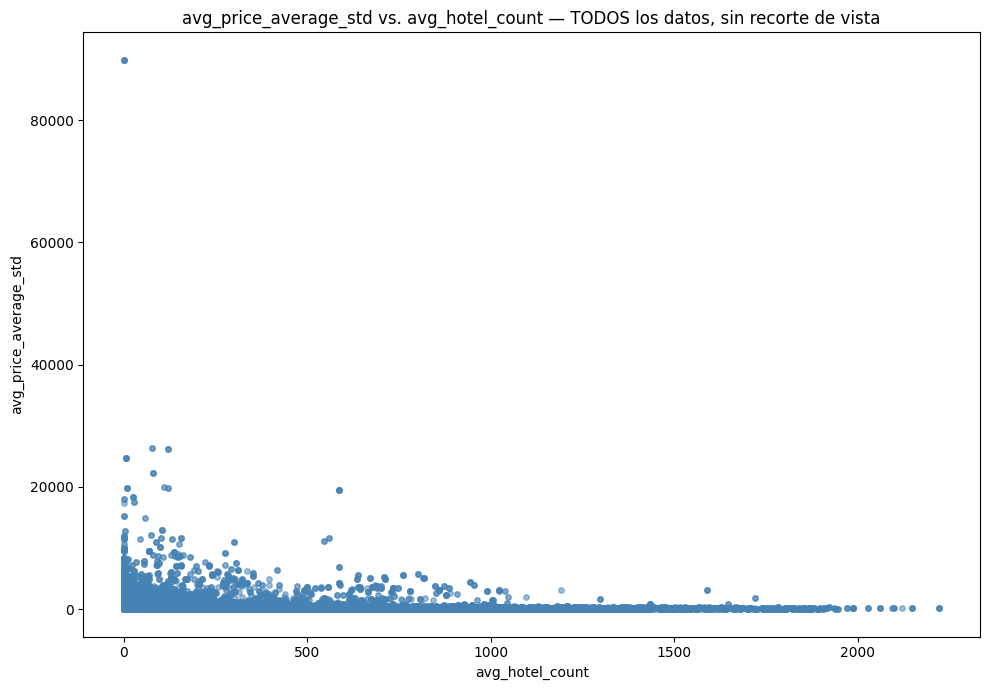

Correlación avg_hotel_count-avg_price_average_std, TODO junto: -0.095


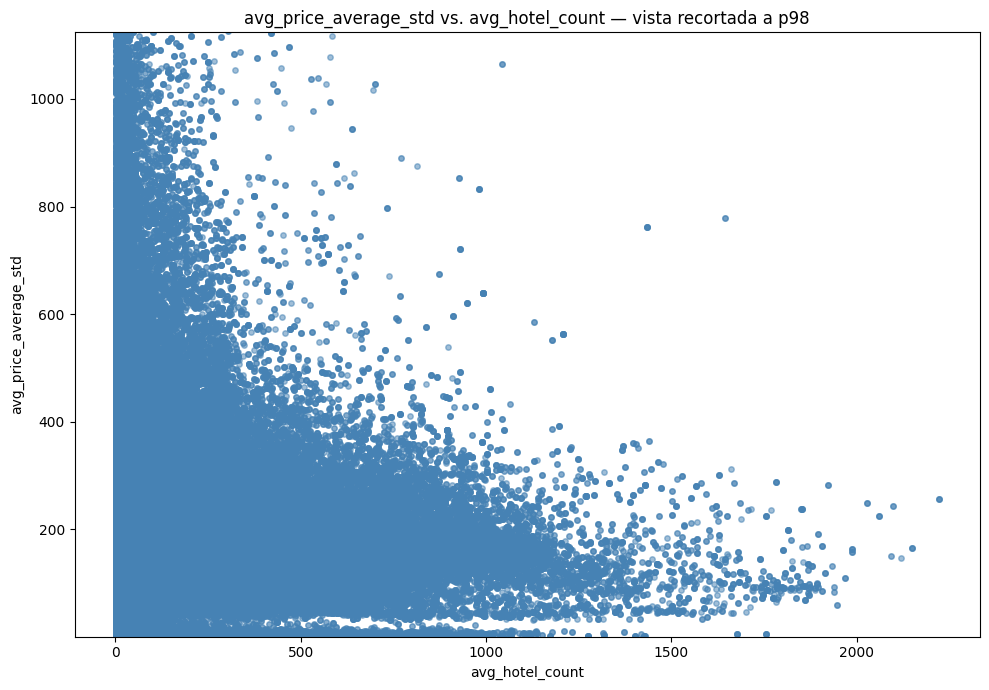

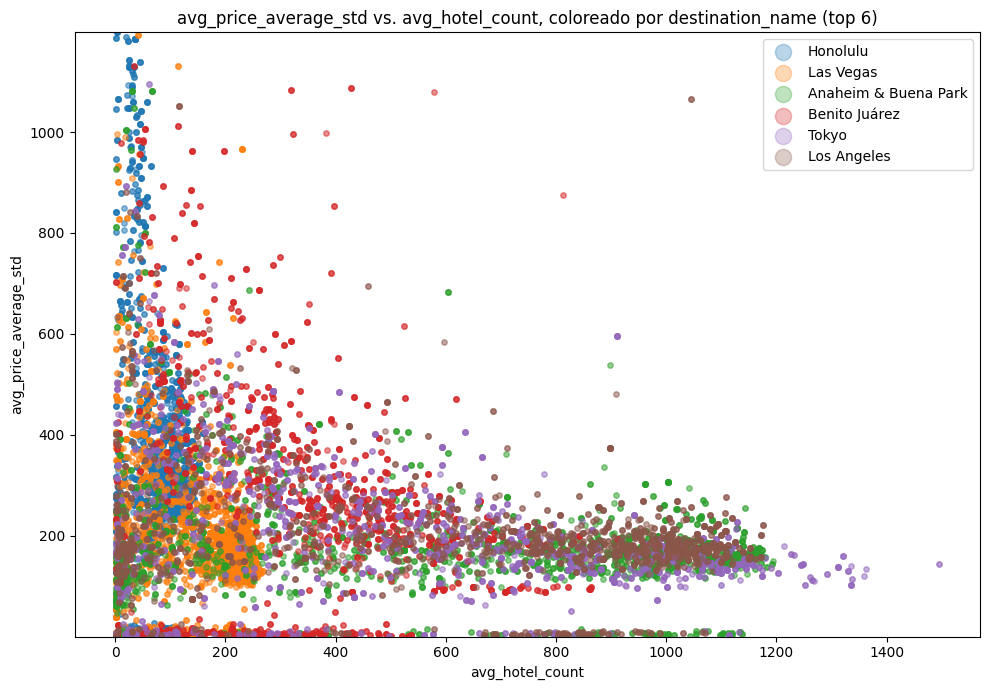


Correlación avg_hotel_count-avg_price_average_std, POR destination_name:
  Honolulu            : -0.192
  Las Vegas           : -0.178
  Anaheim & Buena Park: -0.153
  Benito Juárez       : -0.203
  Tokyo               : -0.210
  Los Angeles         : -0.179


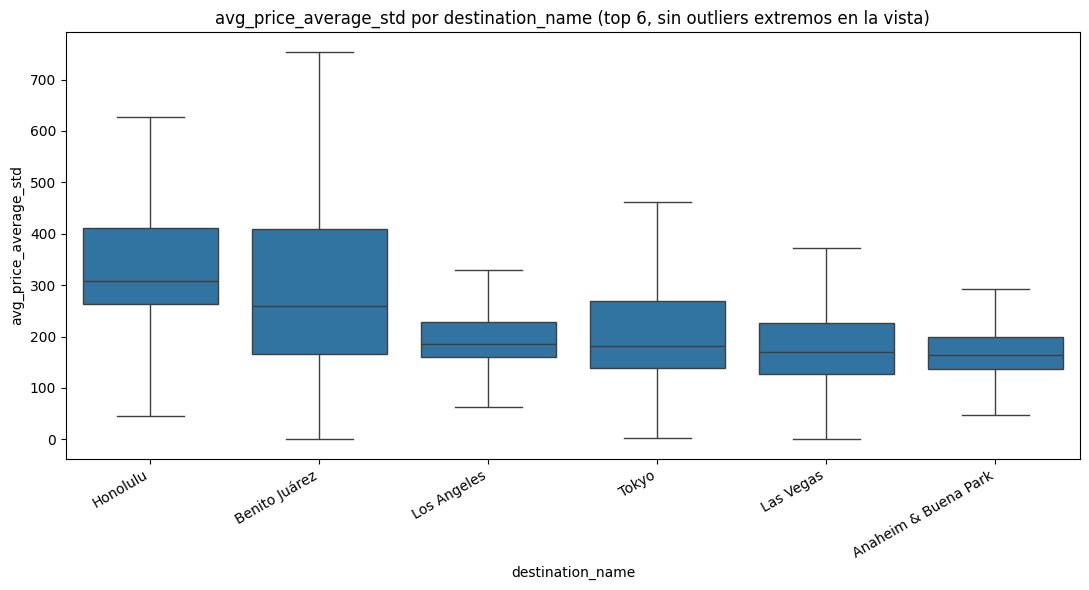

In [ ]:
resultado_destino = analisis_tres_pasos(
    data=df,
    x_col='avg_hotel_count',
    y_col='avg_price_average_std',
    group_col='destination_name',
    top_n=6,
)

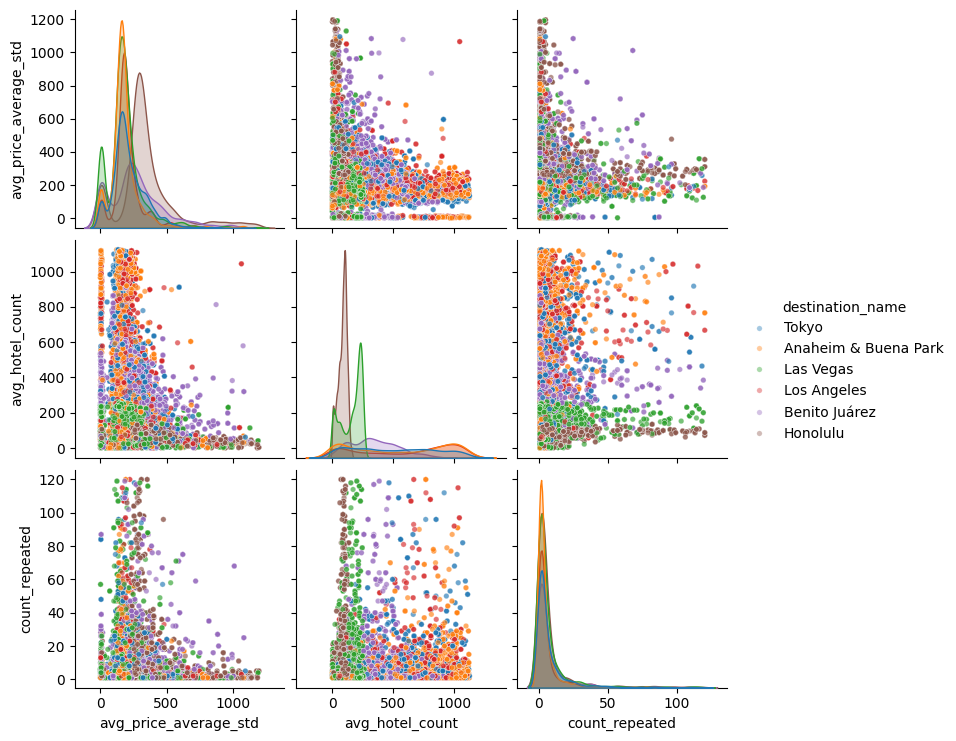

In [ ]:
vars_pairplot = ['avg_price_average_std', 'avg_hotel_count', 'count_repeated']
pairplot_por_grupo(df, vars_pairplot, group_col='destination_name', top_n=6)

**Lectura:** con el mapeo de destinos y el muestreo ya corregidos, las correlaciones individuales quedan agrupadas en un rango angosto (-0.153 a -0.210), sin ningún destino que se despegue del resto. Con los datos limpios, la conclusión es más sólida: la relación oferta-precio es débil de forma consistente en los seis destinos de mayor volumen (Honolulu, Las Vegas, Anaheim & Buena Park, Benito Juárez, Tokyo, Los Ángeles), sin evidencia de heterogeneidad oculta en esta dimensión particular.

### Aplicación 2 — por país

Repetimos el mismo método, ahora agrupando por `country` .

In [ ]:
# Homogeneidad y confiabilidad por país, antes de graficar
var_por_pais = df.groupby('country')['avg_price_average_std'].std().mean()
conteo_pais = df.groupby(['country', 'month', 'week_in_month']).size()
pct_confiable_pais = (conteo_pais >= 30).mean() * 100

print(f'Desvío DENTRO de cada país:           ${var_por_pais:.2f}')
print(f'Confiabilidad (país x mes x semana):  {pct_confiable_pais:.1f}%')

Desvío DENTRO de cada país:           $222.78
Confiabilidad (país x mes x semana):  35.7%


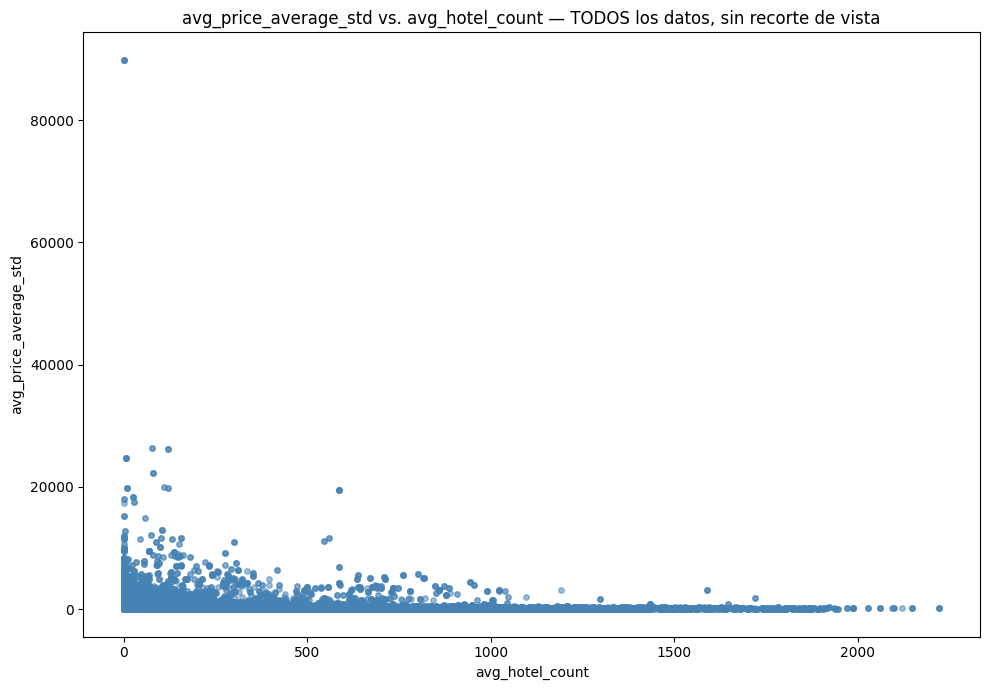

Correlación avg_hotel_count-avg_price_average_std, TODO junto: -0.095


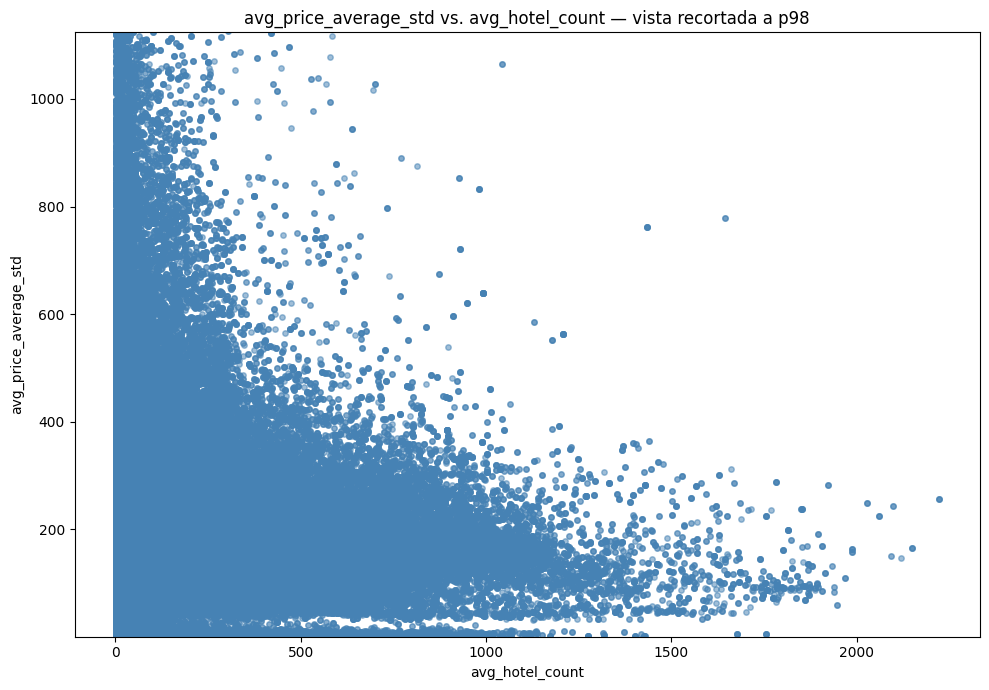

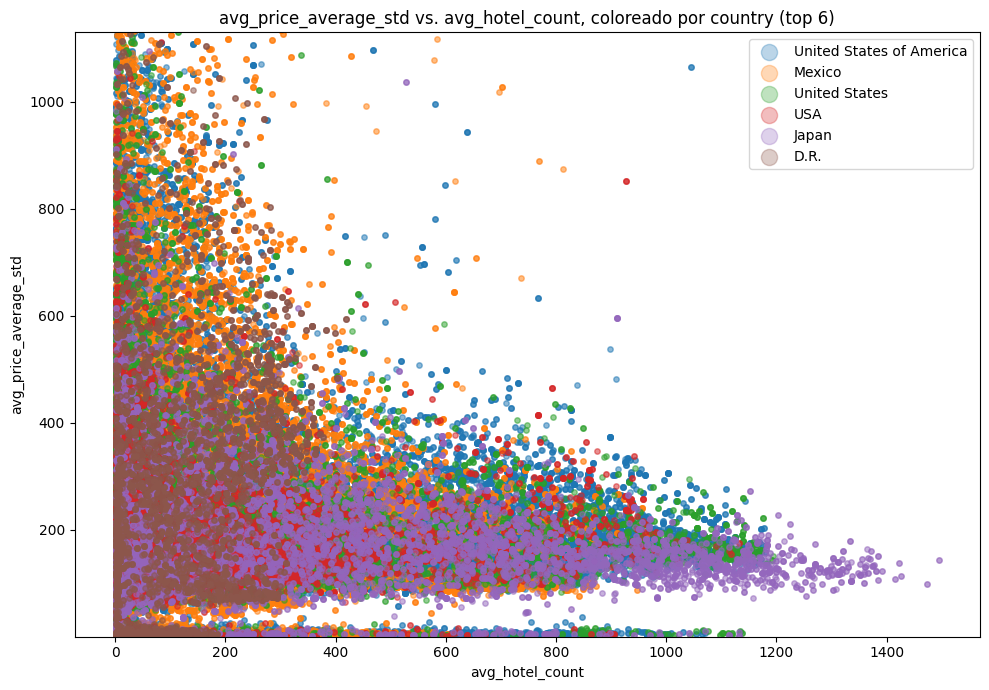


Correlación avg_hotel_count-avg_price_average_std, POR country:
  United States of America: -0.090
  Mexico              : -0.127
  United States       : -0.076
  USA                 : -0.021
  Japan               : -0.156
  D.R.                : 0.047


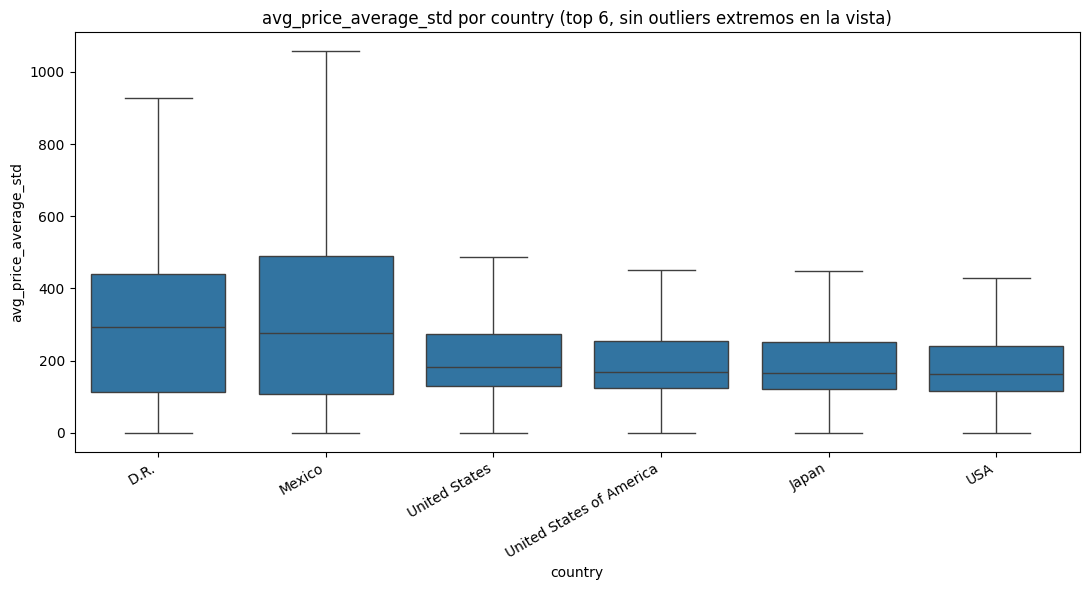

In [ ]:
resultado_pais = analisis_tres_pasos(
    data=df,
    x_col='avg_hotel_count',
    y_col='avg_price_average_std',
    group_col='country',
    top_n=6,
)

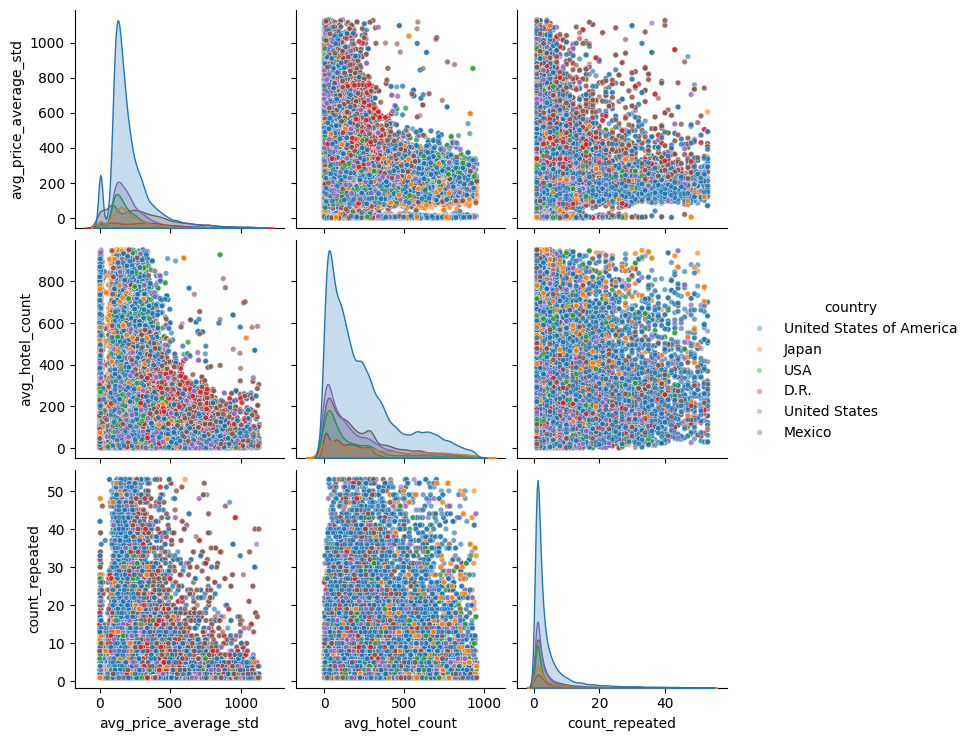

In [ ]:
pairplot_por_grupo(df, vars_pairplot, group_col='country', top_n=6)

**Lectura:**

Comparación destino vs. país: la correlación general es -0.095. Por destino, el rango es angosto y consistente (-0.153 a -0.210), sin heterogeneidad relevante entre los seis destinos principales. Por país el panorama es más desordenado, pero gran parte de ese desorden es artificial: "United States of America", "United States" y "USA" aparecen como tres países distintos, con tres correlaciones distintas (-0.090, -0.076, -0.021). Esto es evidencia directa de que la inconsistencia de nombres de país detectada antes distorsiona análisis reales, y refuerza por qué destino (con el mapeo ya parcialmente corregido) es un nivel de agregación más confiable que país para este dataset.

---
## Paso 9 — TP1: clustering por perfil estacional y prueba de homogeneidad

Complementamos el análisis por destino con un clustering por comportamiento estacional, para evaluar si agrupar destinos por "forma" de precio a lo largo del año da grupos más homogéneos que agrupar por destino individual.

Se calcula el precio mediano por destino y mes, exige al menos 10 observaciones por celda (mes) y se queda solo con destinos que tengan al menos 8 de los 12 meses con datos confiables, es un filtro de calidad antes de clusterizar, para no mezclar destinos con series casi vacías.

Entonces antes de clusterizar hacemos una tabla donde cada fila sea un destino y cada columna un mes, con el precio típico de ese destino en ese mes.
Tres pasos:

**conteo_mes / meses_validos:** para cada combinación destino-mes, contás cuántas observaciones hay. Si un mes tiene menos de 10 observaciones para ese destino, ese dato no es confiable (podés tener un solo búsqueda rara metiendo ruido).

**perfil:** la mediana de precio por destino-mes (mediana en vez de promedio, porque es más robusta a outliers).

**perfil_filtrado:** tacha (pone NaN) las celdas mes-destino que no pasaron el filtro de confiabilidad del paso 1.

**Filtro de cobertura:** si a un destino le faltan demasiados meses (menos de 8 de 12 confiables), lo sacás directamente — no tiene sentido clusterizar una serie temporal con medio año de agujeros.

**fillna(row.mean()):** a los destinos que sí pasaron el filtro, si les falta algún mes suelto (tienen 8, 9, 10 u 11 de 12), rellenás ese hueco puntual con el promedio de ese mismo destino — esta es la única imputación de toda la notebook, y es acotada (rellena huecos chicos, no series enteras).

Resultado: una matriz destino × mes, sin agujeros, solo con destinos confiables.


In [ ]:
# Un mes solo cuenta como válido si tiene al menos 10 observaciones
conteo_mes = df.groupby(['destination_name', 'month']).size().unstack()
meses_validos = conteo_mes >= 10

# Precio mediano por destino y mes (mediana, robusta a valores extremos)
perfil = df.groupby(['destination_name', 'month'])['avg_price_average_std'].median().unstack()
perfil_filtrado = perfil.where(meses_validos)

# Nos quedamos con destinos que tengan al menos 8 de los 12 meses confiables
cobertura = perfil_filtrado.notna().sum(axis=1)
perfil_valido = perfil_filtrado[cobertura >= 8].copy()
perfil_valido = perfil_valido.apply(lambda row: row.fillna(row.mean()), axis=1)

print(f'Destinos con perfil mensual confiable: {len(perfil_valido)} de {df["destination_name"].nunique():,} totales')

Destinos con perfil mensual confiable: 428 de 8,921 totales


Separaramos "nivel" de "forma": Si clusterizaramos directo sobre los precios en dólares, el algoritmo agruparía por cuán caro es el destino en general en vez de por cómo varía en el año.

**nivel:** el precio promedio anual de cada destino (un número por destino).

**forma:** cada mes dividido por nivel, entonces queda como un índice alrededor de 1.0 (1.2 = ese mes un 20% más caro que el promedio del destino, 0.8 = un 20% más barato), sin importar si el destino es caro o barato.

In [ ]:
nivel = perfil_valido.mean(axis=1)
forma = perfil_valido.div(nivel, axis=0)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Acotamos 'forma' entre 0.4 y 2.0: sin esto, meses con pocos datos residuales
# generaban valores hasta 7x el promedio propio del destino, distorsionando el clustering
forma_acotada = forma.clip(lower=0.4, upper=2.0)

features = forma_acotada.copy()
features['nivel_log'] = np.log(nivel)
features.columns = features.columns.astype(str)

scaler = StandardScaler()
X = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
features['cluster'] = kmeans.fit_predict(X)

print(features['cluster'].value_counts().sort_index())

cluster
0    161
1    267
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import silhouette_score

scores = {}
for k in range(2, 12):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    scores[k] = silhouette_score(X, labels)

for k, s in scores.items():
    print(f'k={k}: silhouette={s:.3f}')

k=2: silhouette=0.183
k=3: silhouette=0.108
k=4: silhouette=0.105
k=5: silhouette=0.105
k=6: silhouette=0.113
k=7: silhouette=0.115
k=8: silhouette=0.098
k=9: silhouette=0.095
k=10: silhouette=0.092
k=11: silhouette=0.100


Calculás el desvío estándar del precio dentro de cada destino vs. dentro de cada cluster. Esto es el mismo criterio de "homogeneidad" que usás en el Paso 13: si agrupar por cluster diera grupos más parecidos internamente que agrupar por destino, el desvío dentro de cluster debería ser menor.

In [ ]:
mapa_cluster = features['cluster'].to_dict()
df['cluster_precio'] = df['destination_name'].map(mapa_cluster)
df_clusterizable = df[df['cluster_precio'].notna()].copy().reset_index(drop=True)

# Homogeneidad: ¿varía más el precio DENTRO de un destino, o DENTRO de un cluster completo?
var_por_destino = df_clusterizable.groupby('destination_name')['avg_price_average_std'].std().mean()
var_por_cluster = df_clusterizable.groupby('cluster_precio')['avg_price_average_std'].std().mean()

print(f'Desvío promedio DENTRO de cada destino:  ${var_por_destino:.2f}')
print(f'Desvío promedio DENTRO de cada cluster:  ${var_por_cluster:.2f}')

Desvío promedio DENTRO de cada destino:  $333.71
Desvío promedio DENTRO de cada cluster:  $709.96


**Lectura:** el desvío promedio dentro de cada cluster estacional es 709,96 y duplica al de cada destino individual $333,71. Sigue
siendo evidencia clara de que agrupar por forma estacional k=2, el valor óptimo
según silhouette, mezcla destinos con precios bastante distintos entre sí

---
## Paso 10 — TP1: efecto día de la semana / fin de semana

Calculamos para cada **noche** de estadía, si el precio normalizado es sistemáticamente distinto entre noches de semana y noches de viernes/sábado, y si ese efecto es igual en todos los destinos o no. Es el mismo patrón de análisis que en el Paso 8: general → por grupo.

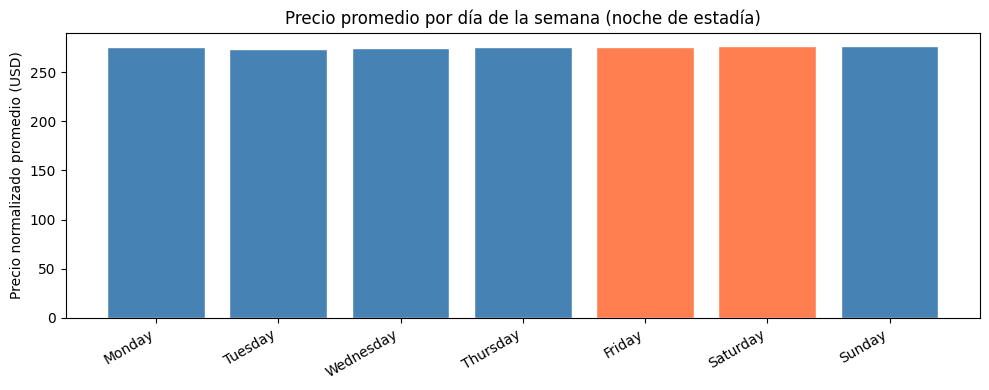

Precio medio noches de semana (dom-jue):         $275.25
Precio medio noches de fin de semana (vie-sab):  $275.84
Efecto fin de semana (global):                   +0.2%


In [ ]:
# Día de la semana de cada noche de estadía y flag de fin de semana.
# Usamos viernes y sábado como "noches de fin de semana" (el check-out del domingo
# implica dormir la noche del sábado, que es la que se paga más cara en la práctica hotelera).
df['weekday'] = df['date'].dt.day_name()
df['weekday_num'] = df['date'].dt.dayofweek  # 0 = lunes ... 6 = domingo
df['is_weekend'] = df['weekday_num'].isin([4, 5])  # viernes, sábado

orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
precio_por_dia = df.groupby('weekday')['avg_price_average_std'].mean().reindex(orden_dias)

fig, ax = plt.subplots(figsize=(10, 4))
colores = ['steelblue'] * 4 + ['coral', 'coral', 'steelblue']
ax.bar(precio_por_dia.index, precio_por_dia.values, color=colores, edgecolor='white')
ax.set_ylabel('Precio normalizado promedio (USD)')
ax.set_title('Precio promedio por día de la semana (noche de estadía)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

precio_finde = df.loc[df['is_weekend'], 'avg_price_average_std'].mean()
precio_semana = df.loc[~df['is_weekend'], 'avg_price_average_std'].mean()
efecto_pct = (precio_finde / precio_semana - 1) * 100

print(f'Precio medio noches de semana (dom-jue):         ${precio_semana:.2f}')
print(f'Precio medio noches de fin de semana (vie-sab):  ${precio_finde:.2f}')
print(f'Efecto fin de semana (global):                   {efecto_pct:+.1f}%')

In [ ]:
# ¿El efecto es igual en todos los destinos, o cambia de signo? (mismo chequeo que
# hicimos con oferta-precio en el Paso 8, ahora aplicado a día de la semana)
top_destinos_finde = df['destination_name'].value_counts().head(8).index

filas = []
for d in top_destinos_finde:
    sub = df[df['destination_name'] == d]
    pf = sub.loc[sub['is_weekend'], 'avg_price_average_std'].mean()
    ps = sub.loc[~sub['is_weekend'], 'avg_price_average_std'].mean()
    filas.append({'destino': d, 'precio_semana': ps, 'precio_finde': pf, 'efecto_pct': (pf / ps - 1) * 100})

efecto_por_destino = pd.DataFrame(filas).sort_values('efecto_pct', ascending=False)
efecto_por_destino

,destino,precio_semana,precio_finde,efecto_pct
1,Las Vegas,201.14,222.94,10.84
4,Tokyo,222.81,234.34,5.17
7,Midtown,399.46,407.02,1.89
0,Honolulu,455.63,463.00,1.62
2,Anaheim & Buena Park,201.08,201.85,0.38
3,Benito Juárez,401.70,379.62,-5.50
5,Los Angeles,234.29,217.41,-7.20
6,Cancún,490.40,454.15,-7.39


**Lectura:** El efecto fin de semana agregado es prácticamente nulo (+0.2%), pero esconde una dispersión real de casi 18 puntos porcentuales entre destinos: desde +10.84% en Las Vegas (el destino de fin de semana por excelencia) hasta -7.39% en Cancún. 5 de los 8 destinos principales muestran efecto positivo, 3 negativo;  no hay un patrón universal, y el promedio agregado (+0.2%) directamente esconde el hallazgo más interesante, que es la heterogeneidad entre destinos y no un efecto único. Las Vegas destacándose como el caso más fuerte es coherente con su perfil de destino de ocio/fin de semana, y es un buen ejemplo concreto de por qué la dimensión "destino" necesita combinarse con "día de la semana" en vez de usarse cada una por separado.

---
## Paso 11 — TP1: duración de la estadía (`nights`) como dimensión

`nights` ya está en el dataset original, pero investigamos si estadías más largas o más cortas tienen un precio normalizado sistemáticamente distinto, y si esa relación es consistente entre destinos. Para esto último reutilizamos la misma función `analisis_tres_pasos` del Paso 8, solo que ahora con `nights` en el eje x.

                mean   count
nights_bucket               
1 noche       201.91   52124
2-3 noches    256.45  139436
4-7 noches    320.57  176319
8-14 noches   266.92   43074
15+ noches    206.31   16096


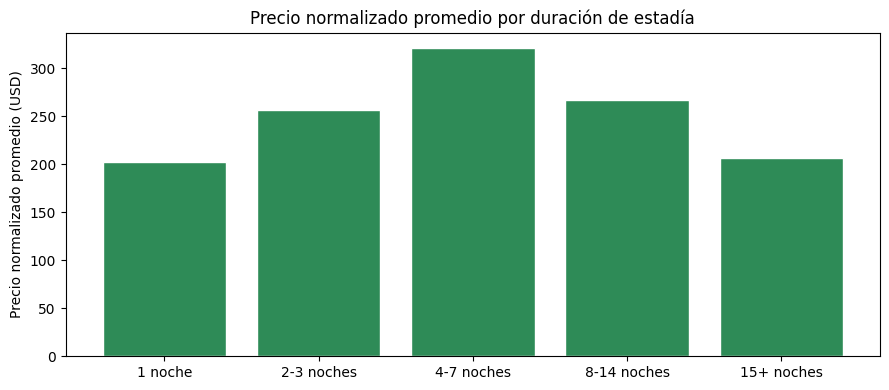


Correlación nights-precio normalizado, TODO junto: 0.004


In [ ]:
# Bucketizamos duración de estadía en rangos con sentido de negocio
bins = [0, 1, 3, 7, 14, np.inf]
labels = ['1 noche', '2-3 noches', '4-7 noches', '8-14 noches', '15+ noches']
df['nights_bucket'] = pd.cut(df['nights'], bins=bins, labels=labels)

precio_por_noches = df.groupby('nights_bucket', observed=True)['avg_price_average_std'].agg(['mean', 'count'])
print(precio_por_noches)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(precio_por_noches.index.astype(str), precio_por_noches['mean'], color='seagreen', edgecolor='white')
ax.set_ylabel('Precio normalizado promedio (USD)')
ax.set_title('Precio normalizado promedio por duración de estadía')
plt.tight_layout()
plt.show()

corr_nights_general = df['nights'].corr(df['avg_price_average_std'])
print(f'\nCorrelación nights-precio normalizado, TODO junto: {corr_nights_general:.3f}')

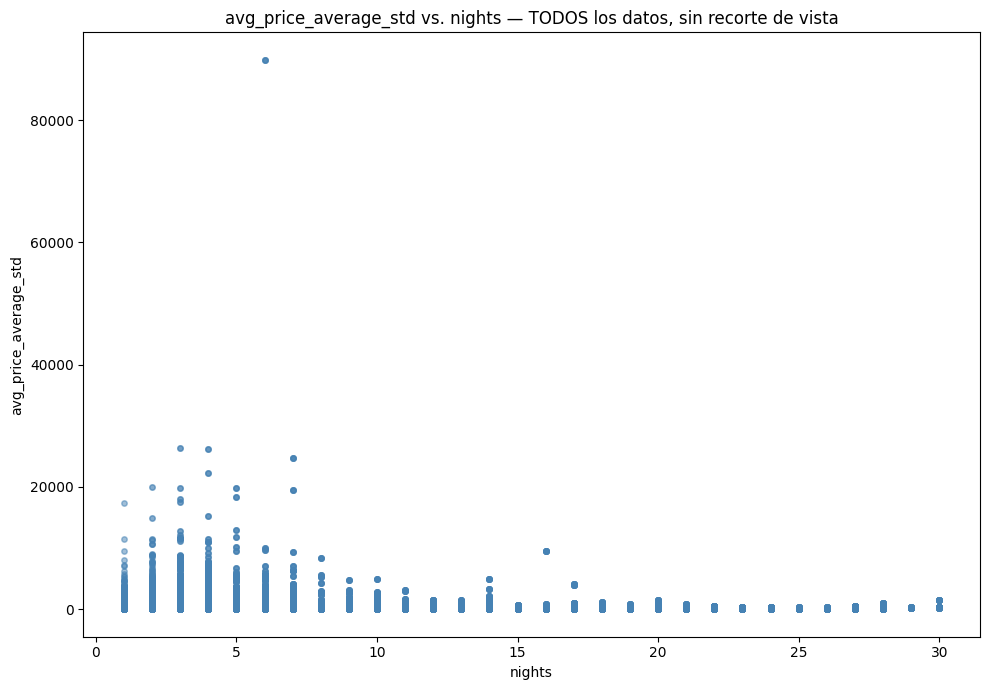

Correlación nights-avg_price_average_std, TODO junto: 0.004


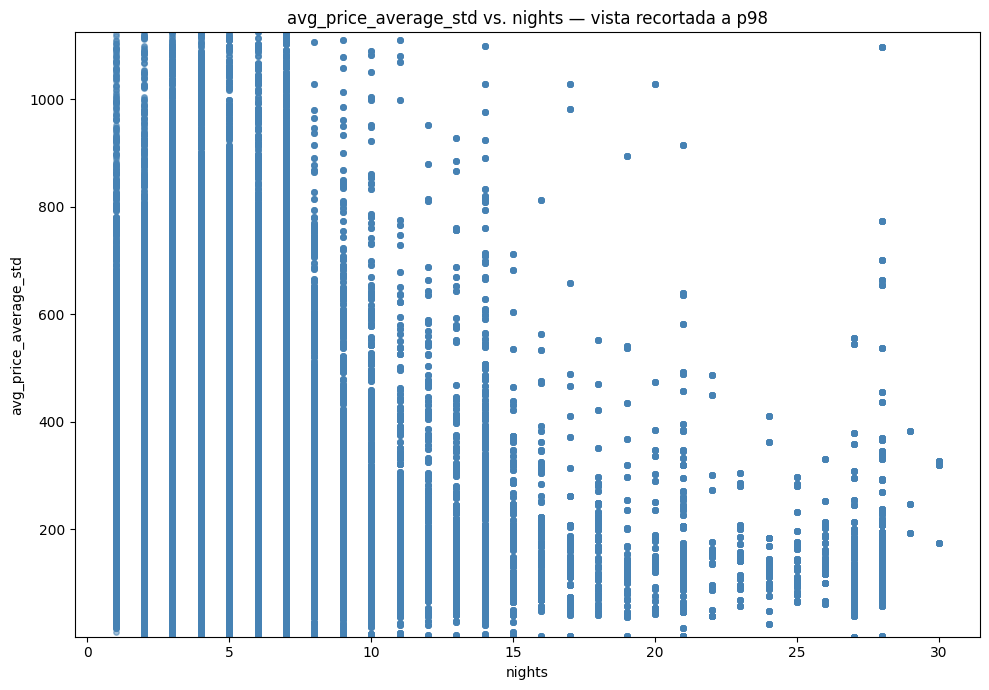

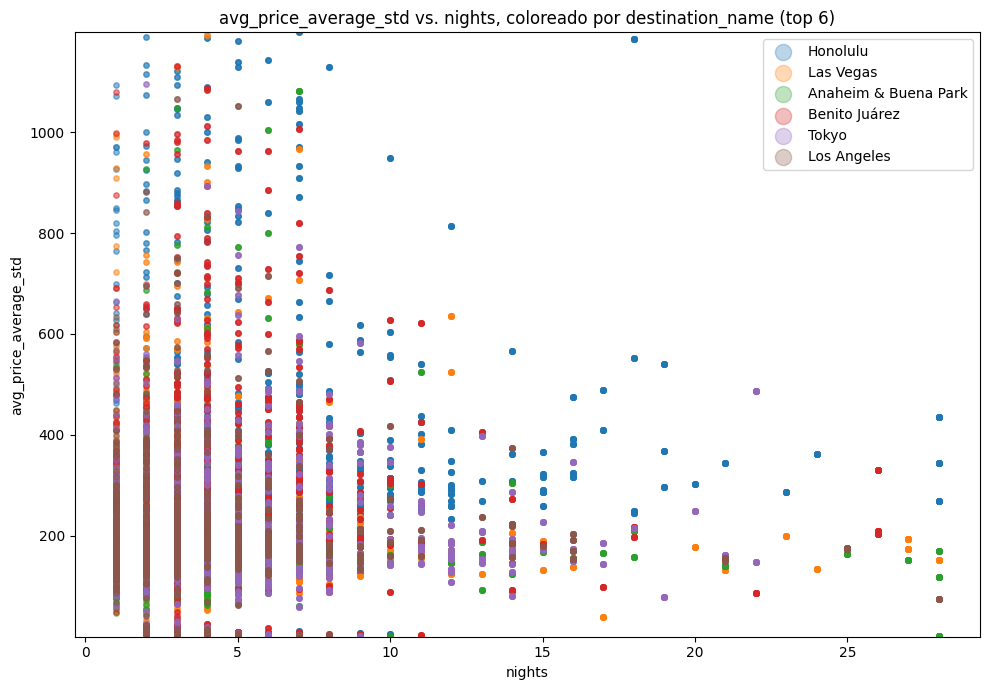


Correlación nights-avg_price_average_std, POR destination_name:
  Honolulu            : 0.036
  Las Vegas           : -0.050
  Anaheim & Buena Park: -0.022
  Benito Juárez       : -0.093
  Tokyo               : -0.036
  Los Angeles         : -0.042


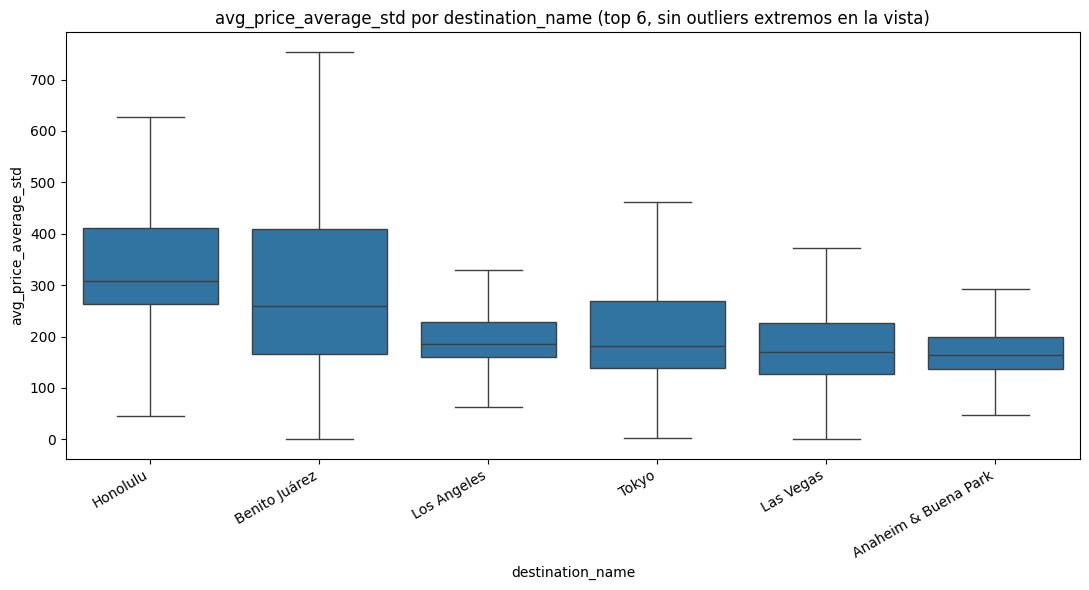

In [ ]:
# Mismo método de 3 pasos del Paso 8, ahora para nights vs. precio, segmentado por destino
resultado_nights = analisis_tres_pasos(
    data=df,
    x_col='nights',
    y_col='avg_price_average_std',
    group_col='destination_name',
    top_n=6,
)

In [ ]:
# Interpretación automática
corrs = list(resultado_nights['correlacion_por_grupo'].values())
rango_txt = f'{min(corrs):.2f} a {max(corrs):.2f}'


print(f'  Correlación general nights-precio: {resultado_nights["correlacion_general"]:.3f}')
print(f'  Rango de correlaciones por destino: {rango_txt}')


  Correlación general nights-precio: 0.004
  Rango de correlaciones por destino: -0.09 a 0.04


**Lectura:** La correlación lineal (nights-precio) es prácticamente nula y consistente entre destinos (-0.09 a 0.04) lo cual sugiere, a primera vista, que la duración de estadía no aporta como dimensión. Pero la tabla de medias por bucket muestra una curva en U invertida real: el precio sube de $201.91 (1 noche) a un máximo de $320.57 (4-7 noches) y después baja a $206.31 (15+ noches). nights sí es una dimensión relevante, pero como bucket categórico, no como variable lineal continua. El mismo patrón que con el efecto fin de semana: mirar solo el promedio/correlación agregada esconde la relación real.

---
## Paso 12 — TP1: categoría de precio del hotel (segmento low/medium/high) como dimensión

Usamos las mismas funciones (`calculate_price_distribution_by_destination` y `classify_observations_into_buckets` de `auxiliary_functions.py`) para asignarle a cada observación un segmento `low` / `medium` / `high` según los percentiles p25/p75 **de su propio destino** — así el segmento es relativo al mercado local, no a un umbral global. La pregunta es: *¿los hoteles más caros de un destino siguen su propia dinámica, independiente del mercado general?*

In [ ]:
from auxiliary_functions import calculate_price_distribution_by_destination, classify_observations_into_buckets

price_dist_tp1 = calculate_price_distribution_by_destination(df)
df = classify_observations_into_buckets(df, price_dist_tp1)  # agrega price_bucket y relative_price_index

df['price_bucket'].value_counts()

,count
price_bucket,
medium,179241
high,128775
low,111960


In [ ]:
# ¿El efecto fin de semana (Paso 10) es igual en los 3 segmentos de precio,
# o los hoteles premium se comportan distinto?
tabla_finde_por_bucket = df.groupby('price_bucket', observed=True).apply(
    lambda g: pd.Series({
        'precio_semana': g.loc[~g['is_weekend'], 'avg_price_average_std'].mean(),
        'precio_finde':  g.loc[g['is_weekend'], 'avg_price_average_std'].mean(),
    }),
)
tabla_finde_por_bucket['efecto_pct'] = (
    tabla_finde_por_bucket['precio_finde'] / tabla_finde_por_bucket['precio_semana'] - 1
) * 100
tabla_finde_por_bucket = tabla_finde_por_bucket.reindex(['low', 'medium', 'high'])
tabla_finde_por_bucket

/tmp/ipykernel_17743/3620486299.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabla_finde_por_bucket = df.groupby('price_bucket', observed=True).apply(


,precio_semana,precio_finde,efecto_pct
price_bucket,,,
low,114.16,111.35,-2.46
medium,229.76,227.91,-0.80
high,484.95,458.01,-5.56


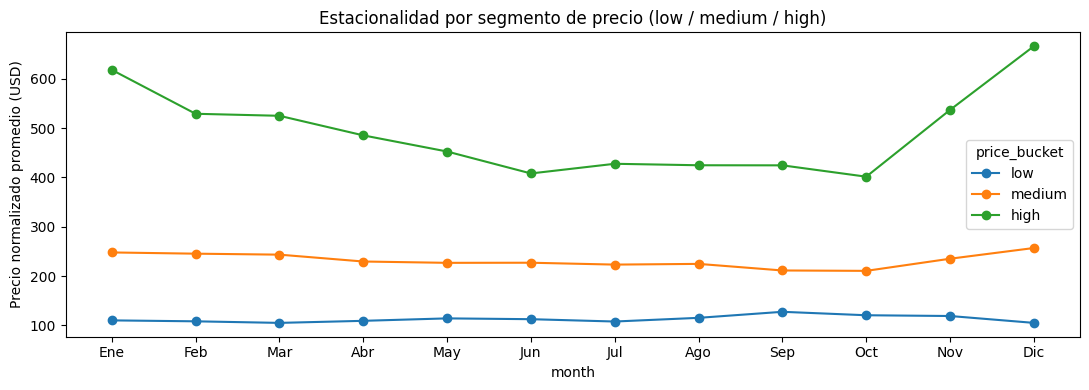

Amplitud del ciclo estacional (max-min mensual) por segmento:
price_bucket
low       22.48
medium    46.37
high     264.77
dtype: float64

 el segmento "high" es el que muestra mayor variación estacional en precio normalizado -- su oferta/demanda responde más a la época del año que los otros segmentos, lo que sugiere que ese segmento necesita baselines mensuales más finos que los otros.


In [ ]:
# Estacionalidad por segmento de precio: ¿el segmento premium tiene un ciclo anual
# más marcado que el budget, o son parecidos?
precio_mes_bucket = (
    df.groupby(['price_bucket', 'month'], observed=True)['avg_price_average_std']
    .mean()
    .unstack(level=0)
    .reindex(columns=['low', 'medium', 'high'])
)

fig, ax = plt.subplots(figsize=(11, 4))
precio_mes_bucket.plot(ax=ax, marker='o')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
ax.set_ylabel('Precio normalizado promedio (USD)')
ax.set_title('Estacionalidad por segmento de precio (low / medium / high)')
plt.tight_layout()
plt.show()

amplitud = precio_mes_bucket.max() - precio_mes_bucket.min()
print('Amplitud del ciclo estacional (max-min mensual) por segmento:')
print(amplitud)
segmento_mas_estacional = amplitud.idxmax()
print(f'\n el segmento "{segmento_mas_estacional}" es el que muestra mayor '
      'variación estacional en precio normalizado -- su oferta/demanda responde más a la época del '
      'año que los otros segmentos, lo que sugiere que ese segmento necesita baselines mensuales más '
      'finos que los otros.')

**Lectura:** El segmento high tiene una amplitud estacional (264.77) mayor que low (22.48) y  mayor que medium (46.37), una diferencia todavía más marcada que en la corrida anterior. El gráfico muestra un patrón de dos picos: precio alto en enero, un valle hacia septiembre, y una subida fuerte en noviembre-diciembre, consistente con temporada de fiestas de fin de año (Navidad/Año Nuevo) concentrada en el segmento premium, mientras que low y medium se mantienen casi planos todo el año.

---
## Paso 13 — TP1: síntesis — ranking de homogeneidad entre dimensiones candidatas

Hasta acá exploramos destino, país, cluster estacional, día de la semana, duración de estadía y categoría de precio por separado, con lecturas puntuales para cada uno.

Para responder la pregunta central del TP1, con un criterio único en vez de comparar lecturas sueltas, calculamos para cada dimensión candidata cuánto se reduce la dispersión (desvío estándar) del precio normalizado al agrupar por esa dimensión, respecto de la dispersión general. Una reducción mayor significa que esa dimensión separa mejor "precios altos" de "precios bajos" lo que consideramos que es un mejor candidato para definir el contexto de comparación.

In [ ]:
def homogeneidad(data, columna_grupo, columna_valor='avg_price_average_std', min_obs=30):
    """
    Compara el desvío estándar DENTRO de cada grupo (ponderado por tamaño de grupo)
    contra el desvío estándar general. Un ratio más bajo = agrupar por esa columna
    reduce más la dispersión de precio = mejor candidato de segmentación.
    Se excluyen grupos con menos de `min_obs` observaciones (mismo criterio de
    confianza mínima que usa el sistema para baselines).
    """
    global_std = data[columna_valor].std()
    stats = data.groupby(columna_grupo, observed=True)[columna_valor].agg(['std', 'count'])
    stats = stats[stats['count'] >= min_obs]
    std_ponderado = (stats['std'] * stats['count']).sum() / stats['count'].sum()
    return {
        'dimension': columna_grupo,
        'std_global': global_std,
        'std_dentro_grupo_ponderado': std_ponderado,
        'reduccion_pct': (1 - std_ponderado / global_std) * 100,
        'n_grupos_con_min_obs': len(stats),
    }

dimensiones_candidatas = [
    'destination_name', 'country', 'weekday', 'is_weekend',
    'nights_bucket', 'price_bucket', 'month', 'cluster_precio',
]
resumen = pd.DataFrame([homogeneidad(df, d) for d in dimensiones_candidatas])
resumen = resumen.sort_values('reduccion_pct', ascending=False).reset_index(drop=True)
resumen

,dimension,std_global,std_dentro_grupo_ponderado,reduccion_pct,n_grupos_con_min_obs
0,destination_name,615.35,327.98,46.70,1714
1,price_bucket,615.35,413.53,32.80,3
2,country,615.35,435.56,29.22,140
3,month,615.35,551.03,10.45,12
4,nights_bucket,615.35,578.20,6.04,5
5,weekday,615.35,615.31,0.01,7
6,is_weekend,615.35,615.34,0.00,2
7,cluster_precio,615.35,714.73,-16.15,2


Probamos si combinar destino con la mejor dimensión no geográfica ayuda más que cada una por separado.

In [ ]:


mejor_no_geo = (
    resumen[~resumen['dimension'].isin(['destination_name', 'country', 'cluster_precio'])]
    .iloc[0]['dimension']
)
df['destino_x_mejor_dim'] = df['destination_name'].astype(str) + ' | ' + df[mejor_no_geo].astype(str)
combo = homogeneidad(df, 'destino_x_mejor_dim')

red_destino = resumen.loc[resumen.dimension == 'destination_name', 'reduccion_pct'].values[0]
red_otra = resumen.loc[resumen.dimension == mejor_no_geo, 'reduccion_pct'].values[0]

print(f'Destino solo:                          reducción {red_destino:.1f}%')
print(f'{mejor_no_geo} solo:                    reducción {red_otra:.1f}%')
print(f'Destino x {mejor_no_geo} combinados:    reducción {combo["reduccion_pct"]:.1f}%')
if combo['reduccion_pct'] > max(red_destino, red_otra):
    print('\n-> Combinar ambas dimensiones reduce MÁS la dispersión que cualquiera de las dos por')
    print('   separado: son complementarias.')
else:
    print('\n-> Combinarlas no mejora sobre la mejor dimensión individual (probablemente porque')
    print('   fragmenta demasiado los grupos y pierde masa estadística). Revisar n_grupos_con_min_obs.')

Destino solo:                          reducción 46.7%
price_bucket solo:                    reducción 32.8%
Destino x price_bucket combinados:    reducción 71.2%

-> Combinar ambas dimensiones reduce MÁS la dispersión que cualquiera de las dos por
   separado: son complementarias.


La dimensión individual que más reduce la dispersión de precio es destination_name (46.70%), seguida por segmento de precio (32.80%),con el mapeo de destinos corregido, destino pasó a ser la dimensión más fuerte, superando a segmento de precio.



### Síntesis de hallazgos

- La dimensión individual que más reduce la dispersión de precio es **destination_name (46,70%)**, seguida por **segmento de precio (32,80%)**, con el mapeo de destinos corregido, destino pasó a ser la dimensión más fuerte superando a segmento de precio.
- **País queda descartado** como sustituto de destino: rinde menos (29,22%) y está distorsionado por nombres inconsistentes ("USA" / "United States" / "United States of America" contados por separado).
- **Combinar destino × segmento de precio da 71,2% de reducción** — más que cualquiera de las dos por separado (46,70% y 32,80% individuales), confirmando que son complementarias.
- **El clustering estacional queda descartado**: agrupar por cluster casi cuadruplica la dispersión dentro de grupo respecto de agrupar por destino individual.
- El **efecto fin de semana** (Paso 10) no es uniforme entre destinos (rango -7,39% a +10,84%), y es negativo dentro de cada segmento de precio (-2,46%, -0,80%, -5,56%) pero positivo en el agregado (+0,2%) — paradoja de Simpson.
- **Día de semana no entra como eje primario** porque reduce casi nada la dispersión total (0,01%), pero conviene mantenerlo como chequeo condicional dentro de cada segmento de precio.
- La **duración de la estadía** (Paso 11) no es un buen predictor lineal de precio, pero sí tiene un patrón real no lineal (curva en U invertida por bucket, pico en 4-7 noches) que la correlación no capta.
- El **segmento de precio high** muestra la mayor amplitud estacional, muy por encima de low y medium.

**Hipótesis final propuesta para el TP:** contexto = destino × segmento de precio (`price_bucket`) × mes. Destino es la dimensión individual más fuerte, segmento de precio la complementa muy bien (71,2% combinados), y mes se justifica sobre todo dentro del segmento high, el único con estacionalidad marcada.

---
## Conclusión

El mercado hotelero no es homogéneo, pero la heterogeneidad se concentra en dos dimensiones: **destino** (reduce la dispersión de precio 46,70%) y **segmento de precio** (32,80%), que combinadas llegan a 71,2% de reducción. País y clustering estacional quedan descartados como candidatos de segmentación: país por nombres inconsistentes ("USA"/"United States"/"United States of America" figuran como tres países distintos), y cluster estacional porque empeora la homogeneidad respecto de agrupar por destino individual (desvío dentro de cluster ~2,13x mayor que dentro de destino).

Día de semana y duración de estadía aportan poco en el agregado, pero esconden patrones reales que el promedio o la correlación lineal no capturan: el efecto fin de semana es +0,2% agregado pero se invierte a negativo dentro de cada segmento de precio, y `nights` tiene correlación lineal casi nula (r=0,004) pero una relación real en forma de U invertida por bucket (pico en 4-7 noches).

Corregir el bug de mapeo de destinos (que dejaba sin consolidar al 70,8% de los registros) cambió resultados sustantivos, no solo cosméticos — destino pasó a ser la dimensión más fuerte del ranking, desplazando a segmento de precio.

**Conclusión final:** destino × segmento de precio (`price_bucket`) × mes, con día de semana como chequeo condicional dentro de cada segmento (no como eje primario).



---
####ANEXO

In [ ]:
import statsmodels.formula.api as smf

# Acotar destino a los 20 más frecuentes -- el resto cae en "Otros" para que
# el modelo no termine con miles de dummies inestables
top_destinos = df['destination_name'].value_counts().head(20).index
df_reg = df.copy()
df_reg['destino_reg'] = df_reg['destination_name'].where(
    df_reg['destination_name'].isin(top_destinos), 'Otros'
)

modelo = smf.ols(
    'avg_price_average_std ~ C(destino_reg) + C(month) + is_weekend + nights + I(nights**2) + avg_hotel_count',
    data=df_reg
).fit()

print(modelo.summary())
print()
print(f'R² del modelo: {modelo.rsquared:.3f}')
print(f'R² ajustado:   {modelo.rsquared_adj:.3f}')

                              OLS Regression Results                             
Dep. Variable:     avg_price_average_std   R-squared:                       0.024
Model:                               OLS   Adj. R-squared:                  0.023
Method:                    Least Squares   F-statistic:                     289.3
Date:                   Fri, 14 Aug 2026   Prob (F-statistic):               0.00
Time:                           22:41:03   Log-Likelihood:            -3.2881e+06
No. Observations:                 419976   AIC:                         6.576e+06
Df Residuals:                     419940   BIC:                         6.577e+06
Df Model:                             35                                         
Covariance Type:               nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

In [ ]:
coefs = modelo.params.reset_index()
coefs.columns = ['variable', 'coeficiente']
coefs['p_valor'] = modelo.pvalues.values
coefs['significativo'] = coefs['p_valor'] < 0.05

print('--- Efecto de destino (vs. el destino de referencia) ---')
display(coefs[coefs['variable'].str.contains('destino_reg')].sort_values('coeficiente', ascending=False))

print('\n--- Efecto de mes (vs. enero) ---')
display(coefs[coefs['variable'].str.contains('month')])

print('\n--- Resto de las variables ---')
display(coefs[~coefs['variable'].str.contains('destino_reg|month|Intercept')])

--- Efecto de destino (vs. el destino de referencia) ---


,variable,coeficiente,p_valor,significativo
2,C(destino_reg)[T.Cabo San Lucas],430.77,0.00,True
19,C(destino_reg)[T.San José del Cabo],373.85,0.00,True
14,C(destino_reg)[T.Midtown],199.58,0.00,True
3,C(destino_reg)[T.Cancún],177.13,0.00,True
10,C(destino_reg)[T.Honolulu],129.73,0.00,True
1,C(destino_reg)[T.Benito Juárez],125.05,0.00,True
9,C(destino_reg)[T.Higüey],112.49,0.00,True
8,C(destino_reg)[T.Friusa],108.07,0.00,True
13,C(destino_reg)[T.Miami],60.65,0.00,True
12,C(destino_reg)[T.Los Angeles],29.29,0.03,True



--- Efecto de mes (vs. enero) ---


,variable,coeficiente,p_valor,significativo
21,C(month)[T.2],-6.31,0.18,False
22,C(month)[T.3],-8.67,0.06,False
23,C(month)[T.4],-36.08,0.00,True
24,C(month)[T.5],-50.53,0.00,True
25,C(month)[T.6],-59.87,0.00,True
26,C(month)[T.7],-56.63,0.00,True
27,C(month)[T.8],-56.18,0.00,True
28,C(month)[T.9],-58.02,0.00,True
29,C(month)[T.10],-70.13,0.00,True
30,C(month)[T.11],-30.15,0.00,True



--- Resto de las variables ---


,variable,coeficiente,p_valor,significativo
32,is_weekend[T.True],1.07,0.60,False
33,nights,17.31,0.00,True
34,I(nights ** 2),-0.75,0.00,True
35,avg_hotel_count,-0.21,0.00,True


In [ ]:
import statsmodels.formula.api as smf

modelo2 = smf.ols(
    'avg_price_average_std ~ C(month) + nights + I(nights**2) + avg_hotel_count',
    data=df
).fit()

print(modelo2.summary())
print()
print(f'R² del modelo: {modelo2.rsquared:.3f}')
print(f'R² ajustado:   {modelo2.rsquared_adj:.3f}')

                              OLS Regression Results                             
Dep. Variable:     avg_price_average_std   R-squared:                       0.014
Model:                               OLS   Adj. R-squared:                  0.014
Method:                    Least Squares   F-statistic:                     424.0
Date:                   Fri, 14 Aug 2026   Prob (F-statistic):               0.00
Time:                           22:41:05   Log-Likelihood:            -3.2901e+06
No. Observations:                 419976   AIC:                         6.580e+06
Df Residuals:                     419961   BIC:                         6.580e+06
Df Model:                             14                                         
Covariance Type:               nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept   

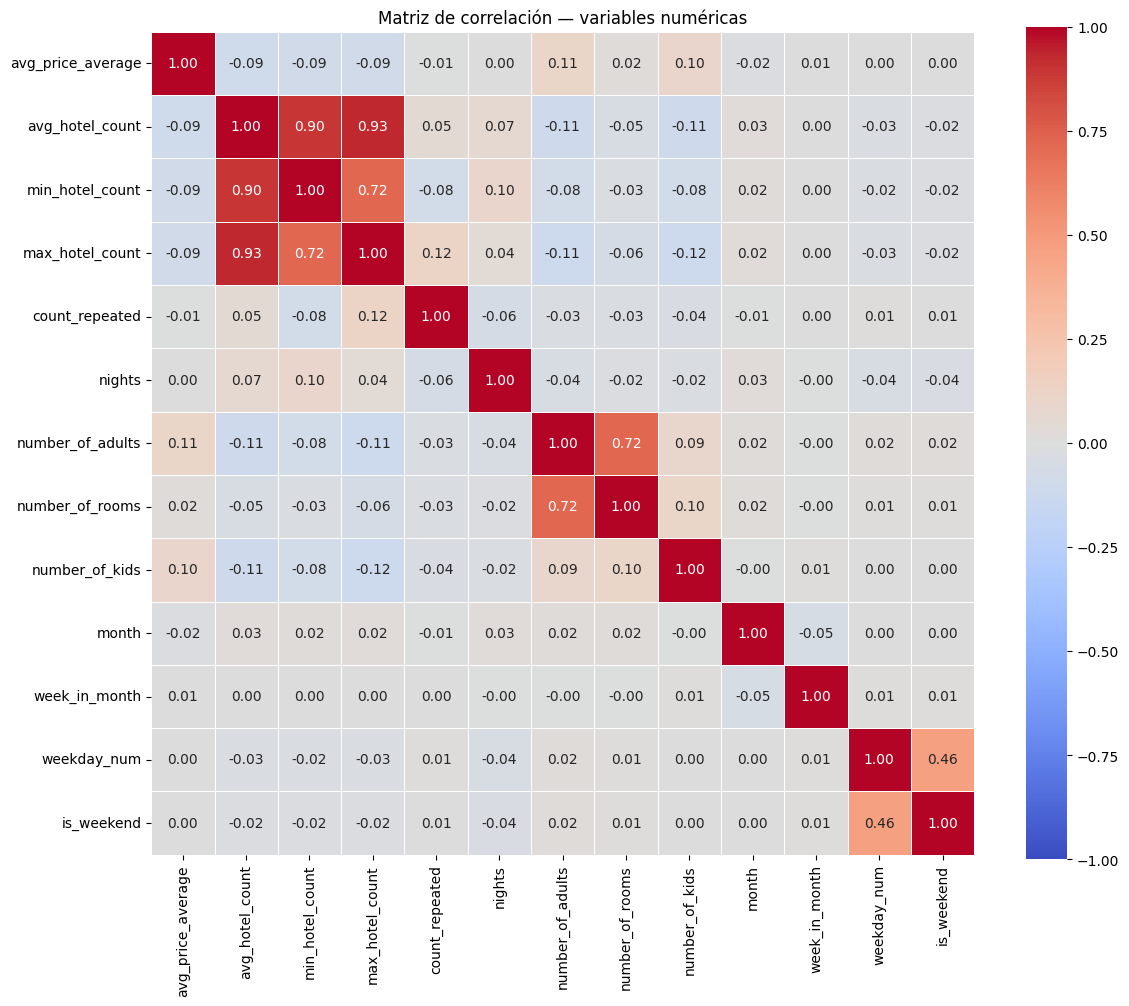

Correlación de cada variable con el precio normalizado, ordenada:
avg_price_average    1.00
number_of_adults     0.11
number_of_kids       0.10
number_of_rooms      0.02
week_in_month        0.01
weekday_num          0.00
nights               0.00
is_weekend           0.00
count_repeated      -0.01
month               -0.02
min_hotel_count     -0.09
max_hotel_count     -0.09
avg_hotel_count     -0.09
Name: avg_price_average, dtype: float64


In [ ]:
# Variables numéricas candidatas -- las categóricas (destino, país, price_bucket,
# nights_bucket, weekday como texto) no entran directo a una matriz de correlación
# lineal; si las querés incluidas hay que codificarlas antes (te lo dejo comentado
# más abajo por si lo necesitás)
cols_numericas = [
    'avg_price_average',   # precio normalizado (tu variable de interés)
    'avg_hotel_count', 'min_hotel_count', 'max_hotel_count',   # oferta
    'count_repeated',            # demanda
    'nights',
    'number_of_adults', 'number_of_rooms', 'number_of_kids',
    'month', 'week_in_month', 'weekday_num', 'is_weekend',
]
cols_numericas = [c for c in cols_numericas if c in df.columns]

df_corr = df[cols_numericas].copy()
df_corr['is_weekend'] = df_corr['is_weekend'].astype(int)  # True/False -> 1/0

matriz_corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de correlación — variables numéricas')
plt.tight_layout()
plt.show()

print('Correlación de cada variable con el precio normalizado, ordenada:')
print(matriz_corr['avg_price_average'].sort_values(ascending=False))

In [ ]:
# Precio relativo: cuántos desvíos estándar está cada búsqueda por encima/debajo
# del promedio de SU PROPIO destino -- misma lógica que evaluate_hotel_price()
df['precio_relativo'] = df.groupby('destination_name')['avg_price_average_std'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# Sacamos destinos con muy pocas observaciones, donde el std calculado es poco confiable
conteo = df['destination_name'].value_counts()
destinos_validos = conteo[conteo >= 30].index
df_rel = df[df['destination_name'].isin(destinos_validos)].dropna(subset=['precio_relativo'])

modelo_rel = smf.ols(
    'precio_relativo ~ C(month) + is_weekend + nights + I(nights**2) + avg_hotel_count',
    data=df_rel
).fit()

print(modelo_rel.summary())
print(f'\nR² ajustado: {modelo_rel.rsquared_adj:.3f}')

                            OLS Regression Results                            
Dep. Variable:        precio_relativo   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     335.1
Date:                Fri, 14 Aug 2026   Prob (F-statistic):               0.00
Time:                        22:41:13   Log-Likelihood:            -5.1276e+05
No. Observations:              363735   AIC:                         1.026e+06
Df Residuals:                  363719   BIC:                         1.026e+06
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.0195      0

In [ ]:
p1, p99 = df_rel['precio_relativo'].quantile([0.01, 0.99])
df_rel_wins = df_rel.copy()
df_rel_wins['precio_relativo'] = df_rel_wins['precio_relativo'].clip(p1, p99)

modelo_rel_wins = smf.ols(
    'precio_relativo ~ C(month) + is_weekend + nights + I(nights**2) + avg_hotel_count',
    data=df_rel_wins
).fit()
print(f'R² ajustado (winsorizado): {modelo_rel_wins.rsquared_adj:.3f}')

R² ajustado (winsorizado): 0.019


In [ ]:
# Precio relativo: cuántos desvíos estándar está cada búsqueda por encima/debajo
# del promedio de SU PROPIO destino -- misma lógica que evaluate_hotel_price()
df['precio_relativo'] = df.groupby('destination_name')['avg_price_average_std'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# Sacamos destinos con muy pocas observaciones, donde el std calculado es poco confiable
conteo = df['destination_name'].value_counts()
destinos_validos = conteo[conteo >= 30].index
df_rel = df[df['destination_name'].isin(destinos_validos)].dropna(subset=['precio_relativo'])

modelo_rel = smf.ols(
    'precio_relativo ~ is_weekend + avg_hotel_count',
    data=df_rel
).fit()

print(modelo_rel.summary())
print(f'\nR² ajustado: {modelo_rel.rsquared_adj:.3f}')

                            OLS Regression Results                            
Dep. Variable:        precio_relativo   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     2018.
Date:                Fri, 14 Aug 2026   Prob (F-statistic):               0.00
Time:                        22:41:19   Log-Likelihood:            -5.1325e+05
No. Observations:              363735   AIC:                         1.027e+06
Df Residuals:                  363732   BIC:                         1.027e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.0818      0

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = pd.DataFrame({
    'is_weekend': df_rel['is_weekend'].astype(int),
    'nights': df_rel['nights'],
    'nights_sq': df_rel['nights'] ** 2,
    'avg_hotel_count': df_rel['avg_hotel_count'],
})
X = sm.add_constant(X)

vif = pd.DataFrame()
vif['variable'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

          variable  VIF
0            const 6.36
1       is_weekend 1.00
2           nights 7.45
3        nights_sq 7.43
4  avg_hotel_count 1.01


In [ ]:
# "Kitchen sink": todo lo disponible que no sea leakage (price_bucket) ni
# redundante (country, cluster_precio ya descartados) -- para ver el techo
# real de lo que estas variables pueden explicar juntas
modelo_completo = smf.ols(
    'precio_relativo ~ C(weekday) + C(month) + avg_hotel_count + count_repeated '
    '+ number_of_adults + number_of_rooms + number_of_kids',
    data=df_rel
).fit()

print(modelo_completo.summary())
print(f'\nR² ajustado: {modelo_completo.rsquared_adj:.3f}')

                            OLS Regression Results                            
Dep. Variable:        precio_relativo   R-squared:                       0.119
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     2230.
Date:                Fri, 14 Aug 2026   Prob (F-statistic):               0.00
Time:                        22:41:26   Log-Likelihood:            -4.9225e+05
No. Observations:              363735   AIC:                         9.845e+05
Df Residuals:                  363712   BIC:                         9.848e+05
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_rel[['avg_hotel_count', 'number_of_adults', 'number_of_rooms', 'number_of_kids']].copy()
X = sm.add_constant(X)

vif = pd.DataFrame()
vif['variable'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

           variable  VIF
0             const 8.91
1   avg_hotel_count 1.03
2  number_of_adults 2.09
3   number_of_rooms 2.07
4    number_of_kids 1.02


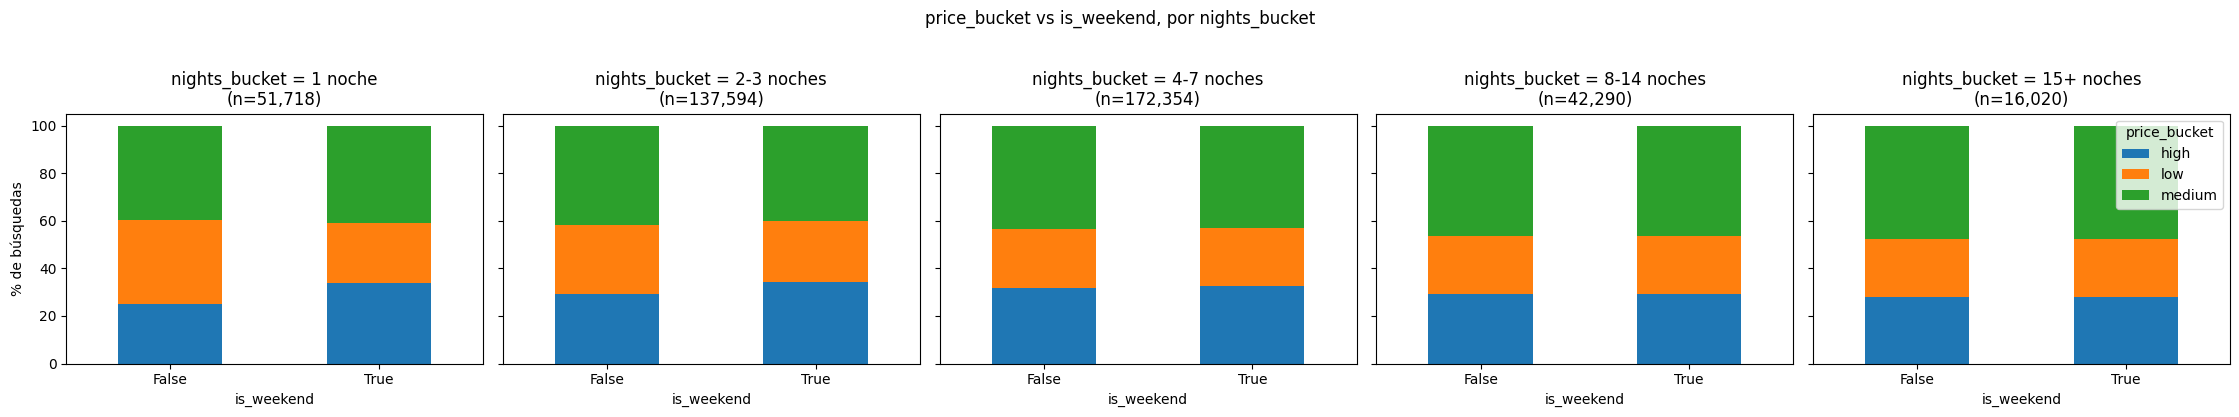

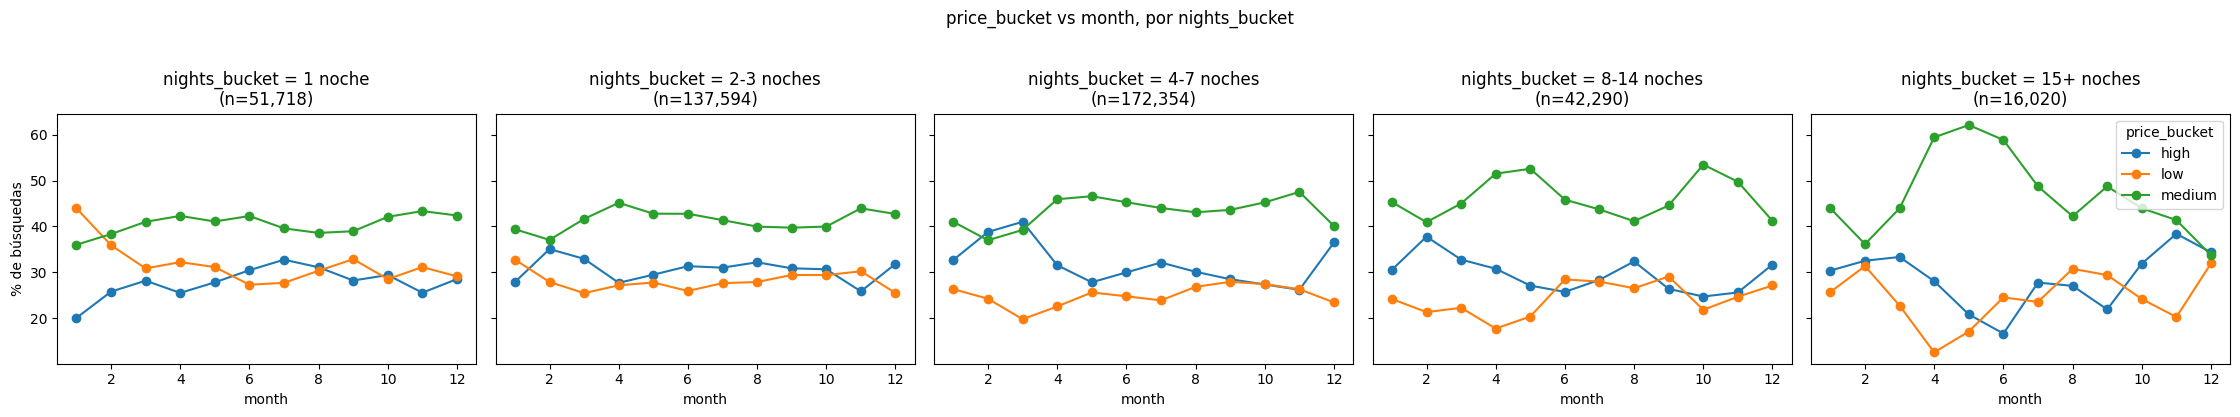

KeyError: 'estacionalidad'

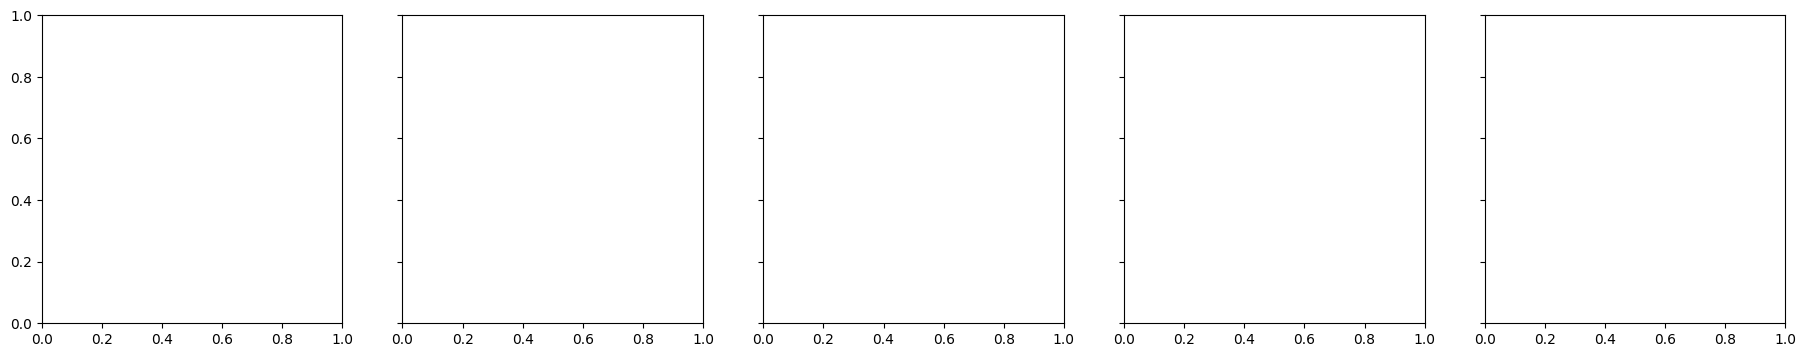

In [ ]:
def crosstab_por_estadia(df, columna_analisis, bucket_col='nights_bucket',
                          price_col='price_bucket', normalize='index', kind='line'):
    """
    Cruza `columna_analisis` con `price_col`, un panel por cada categoría de `bucket_col`.
    kind='line' -> una línea por cada valor de price_bucket (ideal para variables ordinales: month, estacionalidad)
    kind='bar'  -> barras apiladas (ideal para variables binarias/nominales: is_weekend)
    """
    categorias = (df[bucket_col].cat.categories if hasattr(df[bucket_col], 'cat')
                  else sorted(df[bucket_col].dropna().unique()))
    n = len(categorias)
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4), sharey=True)
    if n == 1:
        axes = [axes]

    tablas = {}
    for ax, cat in zip(axes, categorias):
        sub = df[df[bucket_col] == cat]
        tabla = pd.crosstab(sub[columna_analisis], sub[price_col], normalize=normalize) * 100
        tablas[cat] = tabla

        if kind == 'line':
            tabla.plot(kind='line', marker='o', ax=ax, legend=(ax is axes[-1]))
        else:
            tabla.plot(kind='bar', stacked=True, ax=ax, legend=(ax is axes[-1]))

        ax.set_title(f'{bucket_col} = {cat}\n(n={len(sub):,})')
        ax.set_ylabel('% de búsquedas' if ax is axes[0] else '')
        ax.set_xlabel(columna_analisis)
        ax.tick_params(axis='x', rotation=0)

    plt.suptitle(f'{price_col} vs {columna_analisis}, por {bucket_col}', y=1.03)
    plt.tight_layout()
    plt.show()
    return tablas

# --- Llamadas ---
tablas_weekend        = crosstab_por_estadia(df, 'is_weekend', kind='bar')   # binaria -> barras
tablas_mes            = crosstab_por_estadia(df, 'month', kind='line')       # ordinal -> línea
tablas_estacionalidad = crosstab_por_estadia(df, 'estacionalidad', kind='line')  # ordinal -> línea